# Exploratory Data Analysis of Team Attributions (2023 and 2024)


This notebook analyzes team attributions data gathered from the *attributions-form* API for the years 2023 and 2024. It provides graphical visualizations (bar plots, histograms, heatmaps) of task and member distributions, exploring how different member roles (Student, PI, Advisor, etc.) influence the division of work within a typical iGEM team. There are 17 distinct tasks that each team may perform, some requiring broader participation than others. The notebook also explores the network of tasks and their co-occurrence. Its goal is to understand the columns, variations, and patterns in the attributions dataset, to explore how work is distributed within iGEM teams, and to examine and role hierarchy in task participation. 

High school teams can be excluded from analysis since they were not surveyed.

**`attributions_2023_2024` columns:**

* **FullName** – Full name of the team member
* **Username** – Username of the team member
* **TeamID** – Unique team ID associated with the member
* **Team** – Team name (constant across years, but with unique ID)
* **Year** – Year in which the team and member participated
* **Role** – Member’s role (`Student`, `Student Leader`, `Primary PI`, `Advisor`, `Instructor`, `Secondary PI`, `Other`)
* **Task** – Name of the task performed by the member (one row per member-task pair), chosen from:
  `'Investigation'`, `'Background Research'`, `'Notebook Keeping'`, `'Conceptualization'`, `'Project Administration'`, `'Public Engagement'`, `'Writing'`, `'Safety'`, `'Visualization'`, `'Wiki Coding'`, `'Fundraising'`, `'Analysis'`, `'Data Curation'`, `'Software'`, `'Entrepreneurship'`, `'Hardware'`, `'Other'`
* **TaskDescription** – Text description of the performed task;  can be null due to inconsistencies in attribution form submissions (some tasks may not be marked or described)



In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist
import powerlaw
from IPython.display import display

DATASET_ORDER = [
    "2023 Attributions",
    # "2022 BERT Attributions",
    "2022 LLM Attributions",
]

In [63]:
# Plot Configuration

# Color palette
sns.set_palette("deep")

# Styles for seaborn
sns.set_context("notebook", rc={
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.titlepad": 20,     
    "axes.labelpad": 20 
})

# Styles for matplotlib
plt.rcParams.update({
    'axes.titleweight': 'bold',
    'figure.figsize': (12, 8),
    'axes.titlepad': 20,   
    'axes.labelpad': 20,  
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.titlepad": 20,     
    "axes.labelpad": 20 
})

## 1. Basic Data Exploration

- basic exploration (dataframe shape, data types, row counts, null values, computing team sizes)

In [66]:
attributions_df = pd.read_table("../results/attributions/attributions_2023_2024.tsv")
attributions_df = attributions_df[attributions_df["Year"] == 2023].reset_index(drop=True)
attributions_df["Role"] = attributions_df["Role"].replace({"Student": "Student Member"})


attributions_2022_bert = pd.read_table("../results/attributions/attributions_for_surveyed_teams_bert_2022.tsv")
attributions_2022_llm = pd.read_table("../results/attributions/attributions_for_surveyed_teams_llm_2022.tsv")

DATASETS = {
    "2023 Attributions": attributions_df,
    # "2022 BERT Attributions": attributions_2022_bert,
    "2022 LLM Attributions": attributions_2022_llm,
}

In [67]:
# Print number of unique RosterUUID in each dataset
for title in DATASET_ORDER:
    unique_roster_uuids = DATASETS[title]["RosterUUID"].nunique()
    print(f"{title}: {unique_roster_uuids} unique RosterUUIDs")

2023 Attributions: 8210 unique RosterUUIDs
2022 LLM Attributions: 2030 unique RosterUUIDs


Let's look at only **undergrad**, **overgrad**, and **collegiate** teams since **high school** teams were not surveyed. Do not run the next cell if you want to include high school teams. Similarly, we can look at only surveyed teams in 2023 (uncomment second cell).

In [68]:
# Removing high school teams from the analysis
team_meta = pd.read_table("../data/igem_scrapping_2025/team_meta_full.tsv")

meta_2023_2024 = team_meta[(team_meta["Year"] == 2023) | (team_meta["Year"] == 2024)]
grad_teams_2023_2024 = set(meta_2023_2024.loc[meta_2023_2024["Section"] != "high-school", "Team"])

meta_2022 = team_meta[team_meta["Year"] == 2022]
grad_teams_2022 = set(meta_2022.loc[meta_2022["Section"] != "high-school", "Team"])

for title in DATASET_ORDER:
    df = DATASETS[title]
    if "2023" in title:
        keep_teams = grad_teams_2023_2024
    else:
        keep_teams = grad_teams_2022
    DATASETS[title] = df[df["Team"].isin(keep_teams)].reset_index(drop=True)

# Keep the historical variable name for compatibility in downstream code.
attributions_df = DATASETS["2023 Attributions"]

In [69]:
# # Run if you want only surveyed teams in 2023

# survey_tasks_df = pd.read_csv("../data/igem_ties_surveys/2023/survey_tasks.csv")
# survey_teams_unique = survey_tasks_df[['team']].drop_duplicates().reset_index(drop=True)
# attributions_df = attributions_df[attributions_df['Team'].isin(survey_tasks_df['team'])].reset_index(drop=True)

In [70]:
display(pd.concat({title: DATASETS[title].head(5) for title in DATASET_ORDER}, axis=1))

2023 Attributions                                                         \
           FullName         Username                            RosterUUID   
0  Anna Eisenmenger  annaeisenmenger  2ec7e457-28db-4c19-9037-8f641100bd04   
1  Anna Eisenmenger  annaeisenmenger  2ec7e457-28db-4c19-9037-8f641100bd04   
2  Anna Eisenmenger  annaeisenmenger  2ec7e457-28db-4c19-9037-8f641100bd04   
3  Anna Eisenmenger  annaeisenmenger  2ec7e457-28db-4c19-9037-8f641100bd04   
4  Anna Eisenmenger  annaeisenmenger  2ec7e457-28db-4c19-9037-8f641100bd04   

                                                                \
  TeamID    Team  Year            Role                    Task   
0   4574  Munich  2023  Student Member       Conceptualization   
1   4574  Munich  2023  Student Member           Data Curation   
2   4574  Munich  2023  Student Member        Entrepreneurship   
3   4574  Munich  2023  Student Member           Investigation   
4   4574  Munich  2023  Student Member  Project Administration   

                                                     2022 LLM Attributions  \
                                     TaskDescription              FullName   
0          Contribution, Modelling, Entrepreneurship       Claudia Moratti   
1              Interlab Study (Part of Contribution)       Claudia Moratti   
2  Market Analysis, Pitch Deck, iGEM Start Up Sum...       Claudia Moratti   
3              Interlab Study (Part of Contribution)       Mark Somerville   
4  Organisation of meetings (Contribution, Modell...       Mark Somerville   

                                                                 \
         Username                            RosterUUID  TeamID   
0  claudiamoratti  eea7b943-4fbb-4065-905a-65026763fb17  4488.0   
1  claudiamoratti  eea7b943-4fbb-4065-905a-65026763fb17  4488.0   
2  claudiamoratti  eea7b943-4fbb-4065-905a-65026763fb17  4488.0   
3           marks  5e26a4ba-2bb8-4d76-880a-f51450758e97  4488.0   
4           marks  5e26a4ba-2bb8-4d76-880a-f51450758e97  4488.0   

                                                                           
               Team    Year     Role                    Task OutputErrors  
0  Sydney_Australia  2022.0  Advisor  Project administration          NaN  
1  Sydney_Australia  2022.0  Advisor       Conceptualization          NaN  
2  Sydney_Australia  2022.0  Advisor       Public engagement          NaN  
3  Sydney_Australia  2022.0  Advisor       Conceptualization          NaN  
4  Sydney_Australia  2022.0  Advisor     Background research          NaN

In [71]:
for title in DATASET_ORDER:
    print(f"{title}: shape={DATASETS[title].shape}")

2023 Attributions: shape=(26101, 9)
2022 LLM Attributions: shape=(6999, 9)


In [72]:
for title in DATASET_ORDER:
    print(f"\n{title}")
    DATASETS[title].info()


2023 Attributions
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26101 entries, 0 to 26100
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   FullName         26101 non-null  object
 1   Username         26101 non-null  object
 2   RosterUUID       26101 non-null  object
 3   TeamID           26101 non-null  int64 
 4   Team             26101 non-null  object
 5   Year             26101 non-null  int64 
 6   Role             26101 non-null  object
 7   Task             26101 non-null  object
 8   TaskDescription  11317 non-null  object
dtypes: int64(2), object(7)
memory usage: 1.8+ MB

2022 LLM Attributions
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6999 entries, 0 to 6998
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   FullName      6999 non-null   object 
 1   Username      6999 non-null   object 
 2   RosterUUID    6999 non

In [73]:
for title in DATASET_ORDER:
    # if there is a task desqription column, check how many nulls there are, if not, pass
    if 'TaskDescription' in DATASETS[title].columns:
        print(f"{title}: null TaskDescription={DATASETS[title]['TaskDescription'].isnull().sum()}")
    else:
        print(f"{title}: TaskDescription column not found")

2023 Attributions: null TaskDescription=14784
2022 LLM Attributions: TaskDescription column not found


In [74]:
for title in DATASET_ORDER:
    print(f"\n{title}")
    print(sorted(DATASETS[title]["Task"].dropna().unique()))


2023 Attributions
['Analysis', 'Background Research', 'Conceptualization', 'Data Curation', 'Entrepreneurship', 'Fundraising', 'Hardware', 'Investigation', 'Notebook Keeping', 'Other', 'Project Administration', 'Public Engagement', 'Safety', 'Software', 'Visualization', 'Wiki Coding', 'Writing']

2022 LLM Attributions
['Analysis', 'Background research', 'Conceptualization', 'Data curation', 'Entrepreneurship', 'Fundraising', 'Hardware', 'Investigation', 'Lab maintenance', 'Project administration', 'Public engagement', 'Safety', 'Software', 'Visualization', 'Writing']


In [75]:
for title in DATASET_ORDER:
    print(f"\n{title}")
    print(sorted(DATASETS[title]["Role"].dropna().unique()))


2023 Attributions
['Advisor', 'Instructor', 'Other', 'Primary PI', 'Secondary PI', 'Student Leader', 'Student Member']

2022 LLM Attributions
['Advisor', 'Instructor', 'Other', 'Primary PI', 'Secondary PI', 'Student Leader', 'Student Member']


In [76]:
role_tables = {}
for title in DATASET_ORDER:
    role_tables[title] = (
        DATASETS[title]
        .groupby("Role")["FullName"]
        .nunique()
        .rename("unique_member_count")
        .reset_index()
        .sort_values("unique_member_count", ascending=False)
        .reset_index(drop=True)
    )

display(pd.concat(role_tables, axis=1))

2023 Attributions                     2022 LLM Attributions  \
               Role unique_member_count                  Role   
0    Student Member                3573        Student Member   
1           Advisor                 637               Advisor   
2    Student Leader                 502        Student Leader   
3        Instructor                 319            Instructor   
4        Primary PI                 297            Primary PI   
5      Secondary PI                 253          Secondary PI   
6             Other                  40                 Other   

                       
  unique_member_count  
0                1230  
1                 196  
2                 167  
3                 115  
4                 102  
5                  70  
6                  10

In [77]:
for title in DATASET_ORDER:
    df = DATASETS[title]
    teams_2023 = df[df['Year'] == 2023]['TeamID'].nunique() if 'Year' in df.columns else np.nan
    teams_2024 = df[df['Year'] == 2024]['TeamID'].nunique() if 'Year' in df.columns else np.nan
    teams_2022 = df[df['Year'] == 2022]['TeamID'].nunique() if 'Year' in df.columns else np.nan
    if teams_2022:
        print(f"{title} | Number of Grad Teams in 2022: {teams_2022}")
    print(f"{title} | Number of Grad Teams in 2023: {teams_2023}")
    print(f"{title} | Number of Grad Teams in 2024: {teams_2024}")

2023 Attributions | Number of Grad Teams in 2023: 257
2023 Attributions | Number of Grad Teams in 2024: 0
2022 LLM Attributions | Number of Grad Teams in 2022: 101
2022 LLM Attributions | Number of Grad Teams in 2023: 0
2022 LLM Attributions | Number of Grad Teams in 2024: 0


In [78]:
for title in DATASET_ORDER:
    df = DATASETS[title]
    members_2023 = df[df['Year'] == 2023]['FullName'].nunique() if 'Year' in df.columns else np.nan
    members_2024 = df[df['Year'] == 2024]['FullName'].nunique() if 'Year' in df.columns else np.nan
    members_2022 = df[df['Year'] == 2022]['FullName'].nunique() if 'Year' in df.columns else np.nan
    if members_2022:
        print(f"{title} | Number of Grad Participants in 2022: {members_2022}")
    print(f"{title} | Number of Grad Participants in 2023: {members_2023}")
    print(f"{title} | Number of Grad Participants in 2024: {members_2024}")

2023 Attributions | Number of Grad Participants in 2023: 5582
2023 Attributions | Number of Grad Participants in 2024: 0
2022 LLM Attributions | Number of Grad Participants in 2022: 1890
2022 LLM Attributions | Number of Grad Participants in 2023: 0
2022 LLM Attributions | Number of Grad Participants in 2024: 0


In [79]:
team_sizes_by_dataset = {}
for title in DATASET_ORDER:
    team_sizes_by_dataset[title] = (
        DATASETS[title]
        .groupby("TeamID")["FullName"]
        .nunique()
        .rename("team_size")
        .reset_index()
    )

# Keep legacy variable for downstream compatibility.
team_sizes = team_sizes_by_dataset["2023 Attributions"]

display(pd.concat(team_sizes_by_dataset, axis=1))

2023 Attributions           2022 LLM Attributions          
               TeamID team_size                TeamID team_size
0                4574        26                4118.0      17.0
1                4575        19                4133.0       9.0
2                4577        15                4135.0       7.0
3                4578        25                4138.0      33.0
4                4579        20                4139.0      13.0
..                ...       ...                   ...       ...
252              5007        27                   NaN       NaN
253              5016         8                   NaN       NaN
254              5017        18                   NaN       NaN
255              5019        22                   NaN       NaN
256              5027        15                   NaN       NaN

[257 rows x 4 columns]

In [80]:
for title in DATASET_ORDER:
    avg_team_size = team_sizes_by_dataset[title]['team_size'].mean()
    avg_team_size_rounded = math.ceil(avg_team_size)
    print(f"{title}: Average number of team members per team: {avg_team_size_rounded}")

2023 Attributions: Average number of team members per team: 22
2022 LLM Attributions: Average number of team members per team: 19


In [81]:
for title in DATASET_ORDER:
    print(f"{title}: max team size = {team_sizes_by_dataset[title]['team_size'].max()}")

2023 Attributions: max team size = 78
2022 LLM Attributions: max team size = 58


In [82]:
for title in DATASET_ORDER:
    ts = team_sizes_by_dataset[title]
    max_team_row = ts.loc[ts['team_size'].idxmax()]
    print(f"{title} | TeamID with largest team size: {max_team_row['TeamID']}")
    print(f"{title} | Largest team size: {max_team_row['team_size']}")

2023 Attributions | TeamID with largest team size: 4688
2023 Attributions | Largest team size: 78
2022 LLM Attributions | TeamID with largest team size: 4394.0
2022 LLM Attributions | Largest team size: 58.0


## 2. Members per Task

- visualizations of the average number/proportion of members per task 

In [83]:
team_task_counts_by_dataset = {}
for title in DATASET_ORDER:
    team_task_counts_by_dataset[title] = (
        DATASETS[title]
        .groupby(["TeamID", "Task"])["FullName"]
        .nunique()
        .rename("n_people")
        .reset_index()
    )

team_task_counts = team_task_counts_by_dataset["2023 Attributions"]
display(pd.concat(team_task_counts_by_dataset, axis=1))

2023 Attributions                               2022 LLM Attributions  \
                TeamID                 Task n_people                TeamID   
0                 4574             Analysis        8                4118.0   
1                 4574  Background Research       11                4118.0   
2                 4574    Conceptualization       11                4118.0   
3                 4574        Data Curation        4                4118.0   
4                 4574     Entrepreneurship        4                4118.0   
...                ...                  ...      ...                   ...   
3816              5027               Safety        4                   NaN   
3817              5027             Software        5                   NaN   
3818              5027        Visualization        4                   NaN   
3819              5027          Wiki Coding       10                   NaN   
3820              5027              Writing        4                   NaN   

                                    
                     Task n_people  
0                Analysis      3.0  
1     Background research      5.0  
2       Conceptualization      9.0  
3        Entrepreneurship      3.0  
4             Fundraising      2.0  
...                   ...      ...  
3816                  NaN      NaN  
3817                  NaN      NaN  
3818                  NaN      NaN  
3819                  NaN      NaN  
3820                  NaN      NaN  

[3821 rows x 6 columns]

/var/folders/25/xdw_br_122j5ypnmb925dfjw0000gn/T/ipykernel_58345/809330634.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/25/xdw_br_122j5ypnmb925dfjw0000gn/T/ipykernel_58345/809330634.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


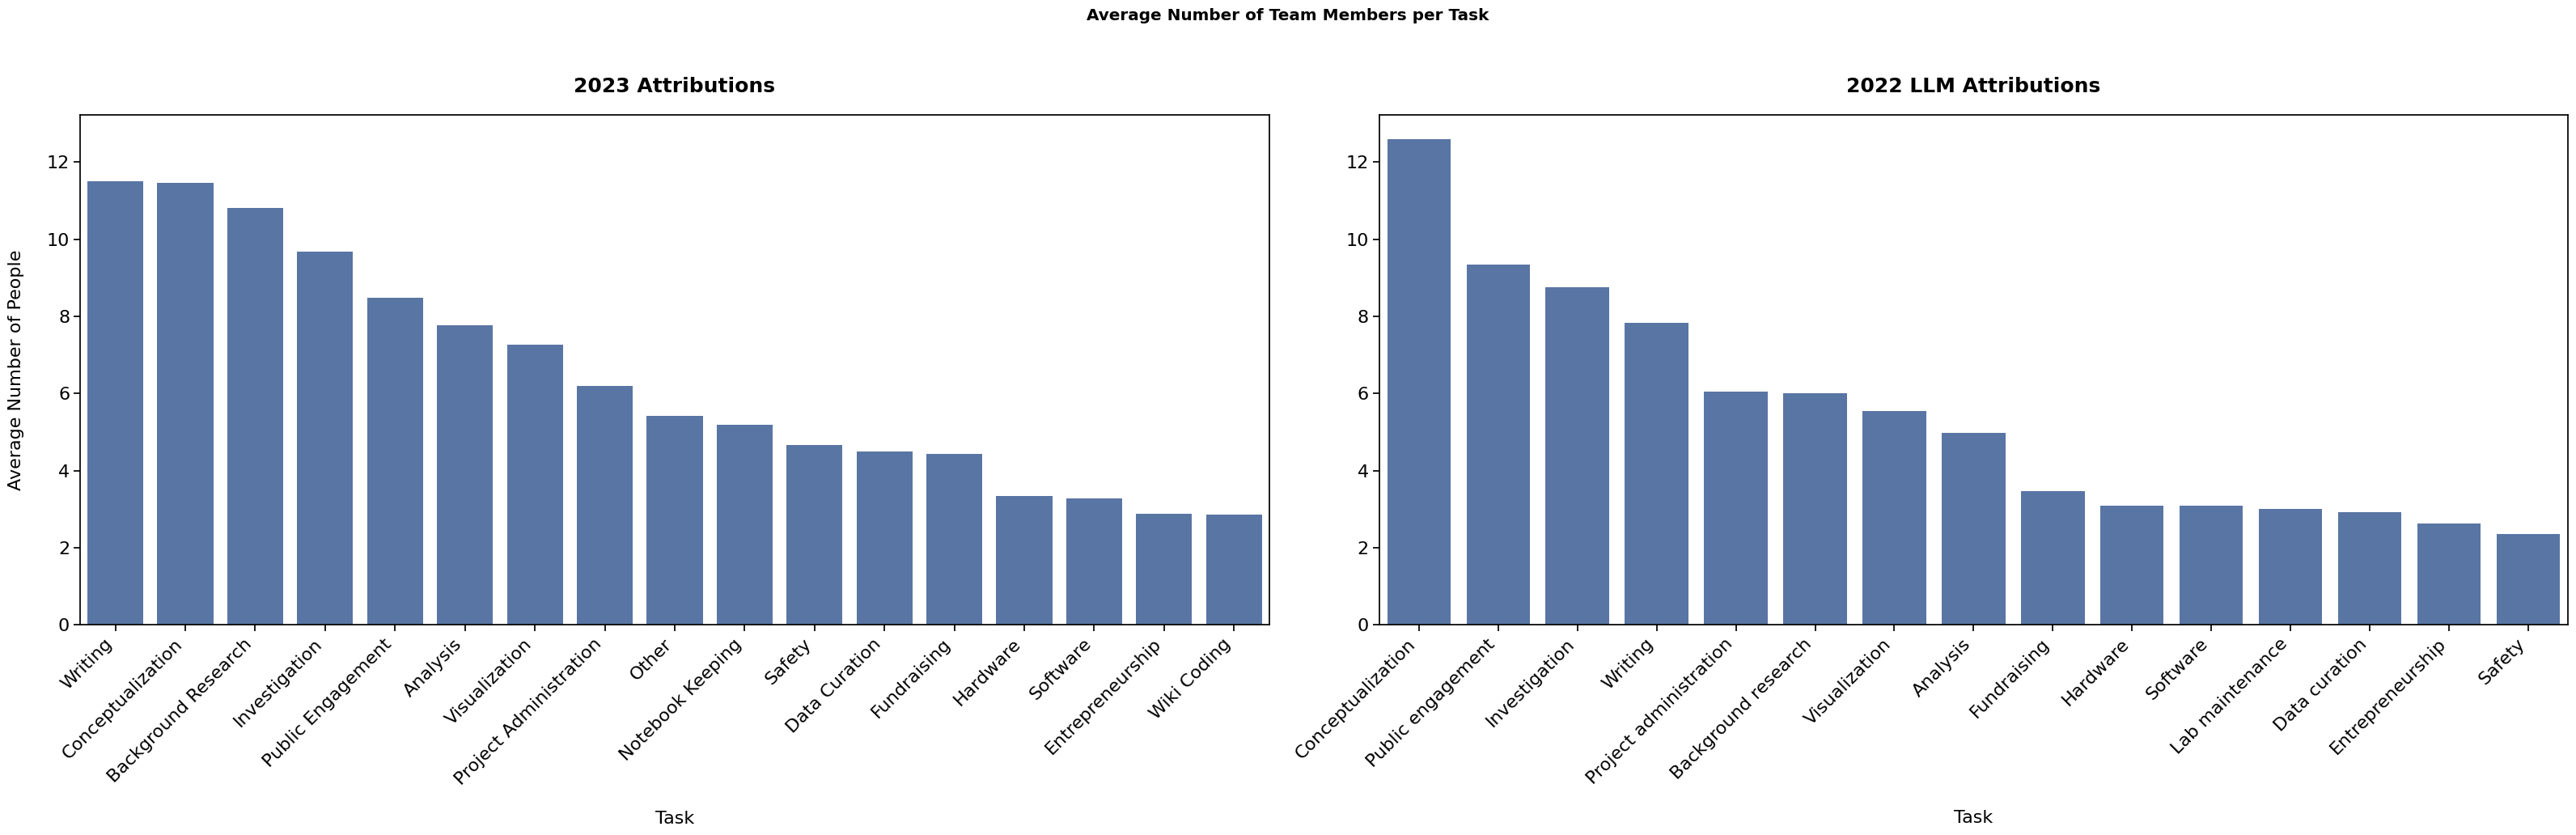

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(32, 10), sharey=True)

for ax, title in zip(axes, DATASET_ORDER):
    avg_people_per_task = (
        team_task_counts_by_dataset[title]
        .groupby("Task")["n_people"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    sns.barplot(
        data=avg_people_per_task,
        x="Task",
        y="n_people",
        order=avg_people_per_task["Task"],
        ax=ax,
    )
    ax.tick_params(axis='y', labelleft=True)
    ax.yaxis.set_label_position("left")
    ax.set_title(title)
    ax.set_xlabel("Task")
    ax.set_ylabel("Average Number of People")
    ax.set_xlim(-0.5, len(avg_people_per_task) - 0.5)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle("Average Number of Team Members per Task", y=1.03, weight='bold')
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.show()


Since teams vary in sizes, we will normalize the bars for team size - make the y-axis average proportions of members performing a certain task within a team.

/var/folders/25/xdw_br_122j5ypnmb925dfjw0000gn/T/ipykernel_58345/3350347385.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/25/xdw_br_122j5ypnmb925dfjw0000gn/T/ipykernel_58345/3350347385.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


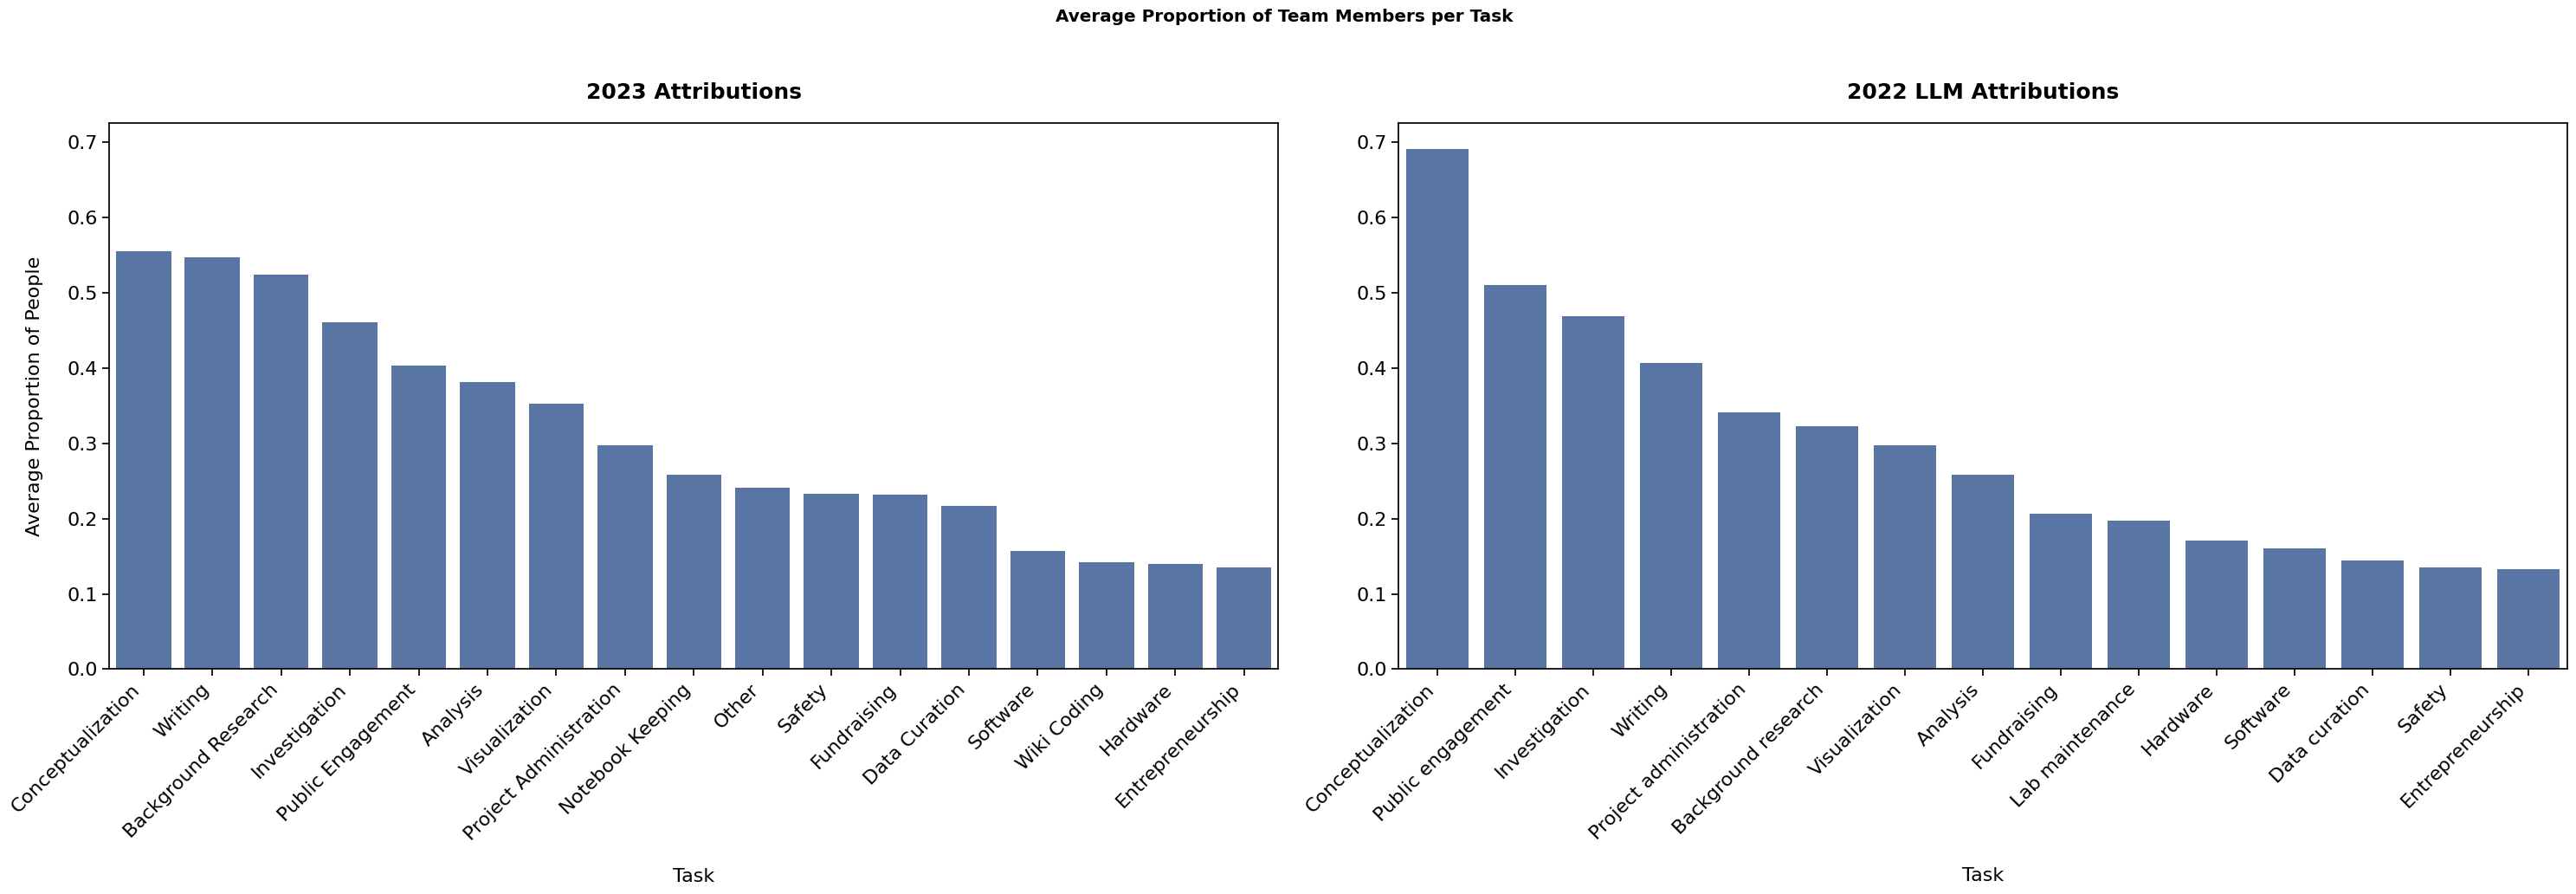

In [ ]:
team_task_prop_by_dataset = {}
fig, axes = plt.subplots(1, 2, figsize=(30, 10), sharey=True)

for ax, title in zip(axes, DATASET_ORDER):
    team_task_prop = team_task_counts_by_dataset[title].merge(team_sizes_by_dataset[title], on="TeamID")
    team_task_prop["prop"] = team_task_prop["n_people"] / team_task_prop["team_size"]
    team_task_prop_by_dataset[title] = team_task_prop

    avg_prop_per_task = (
        team_task_prop
        .groupby("Task")["prop"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    sns.barplot(
        data=avg_prop_per_task,
        x="Task",
        y="prop",
        order=avg_prop_per_task["Task"],
        ax=ax,
    )
    ax.tick_params(axis='y', labelleft=True)
    ax.yaxis.set_label_position("left")
    ax.set_title(title)
    ax.set_xlabel("Task")
    ax.set_ylabel("Average Proportion of People")
    ax.set_xlim(-0.5, len(avg_prop_per_task) - 0.5)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

team_task_prop = team_task_prop_by_dataset["2023 Attributions"]

plt.suptitle("Average Proportion of Team Members per Task", y=1.03, weight='bold')
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.show()


**On average, how many members perform each task within a team?**

 Tasks like writing, conceptualization, background research, and investigation tend to be done by many people in a team (by around 12 members or more than 50%), while tasks like entrepreneurship, hardware, software, and wiki-coding are performed by less people on average (by around 4 members or 5%). 

To take account the fact that some teams have a lot of people doing a certain task while some have only a few people doing the same task, we will add error bars to the previous graph. This helps us visualise these variations of percentages of members across teams.

Firstly, we will compute the percentage of team members performing a task in each team (e.g. 50% of members in team 1 do writing, while 40% of members in team 2 do the writing task). We compute the mean of those team percentages (the bar height), and their standard deviation (how spread out those percentages are). The standard error of the mean is: SEM = standard deviation / sqrt(N), where N is the number of teams. The whiskers on the error bars wll visually represent that SEM (whisker: mean percentage +- SEM). E.g. if the top of the bar is at 30 percent, and the SEM is 5, the whisker will extend up to 35 (and down to 25).

/var/folders/25/xdw_br_122j5ypnmb925dfjw0000gn/T/ipykernel_58345/3701116524.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/25/xdw_br_122j5ypnmb925dfjw0000gn/T/ipykernel_58345/3701116524.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


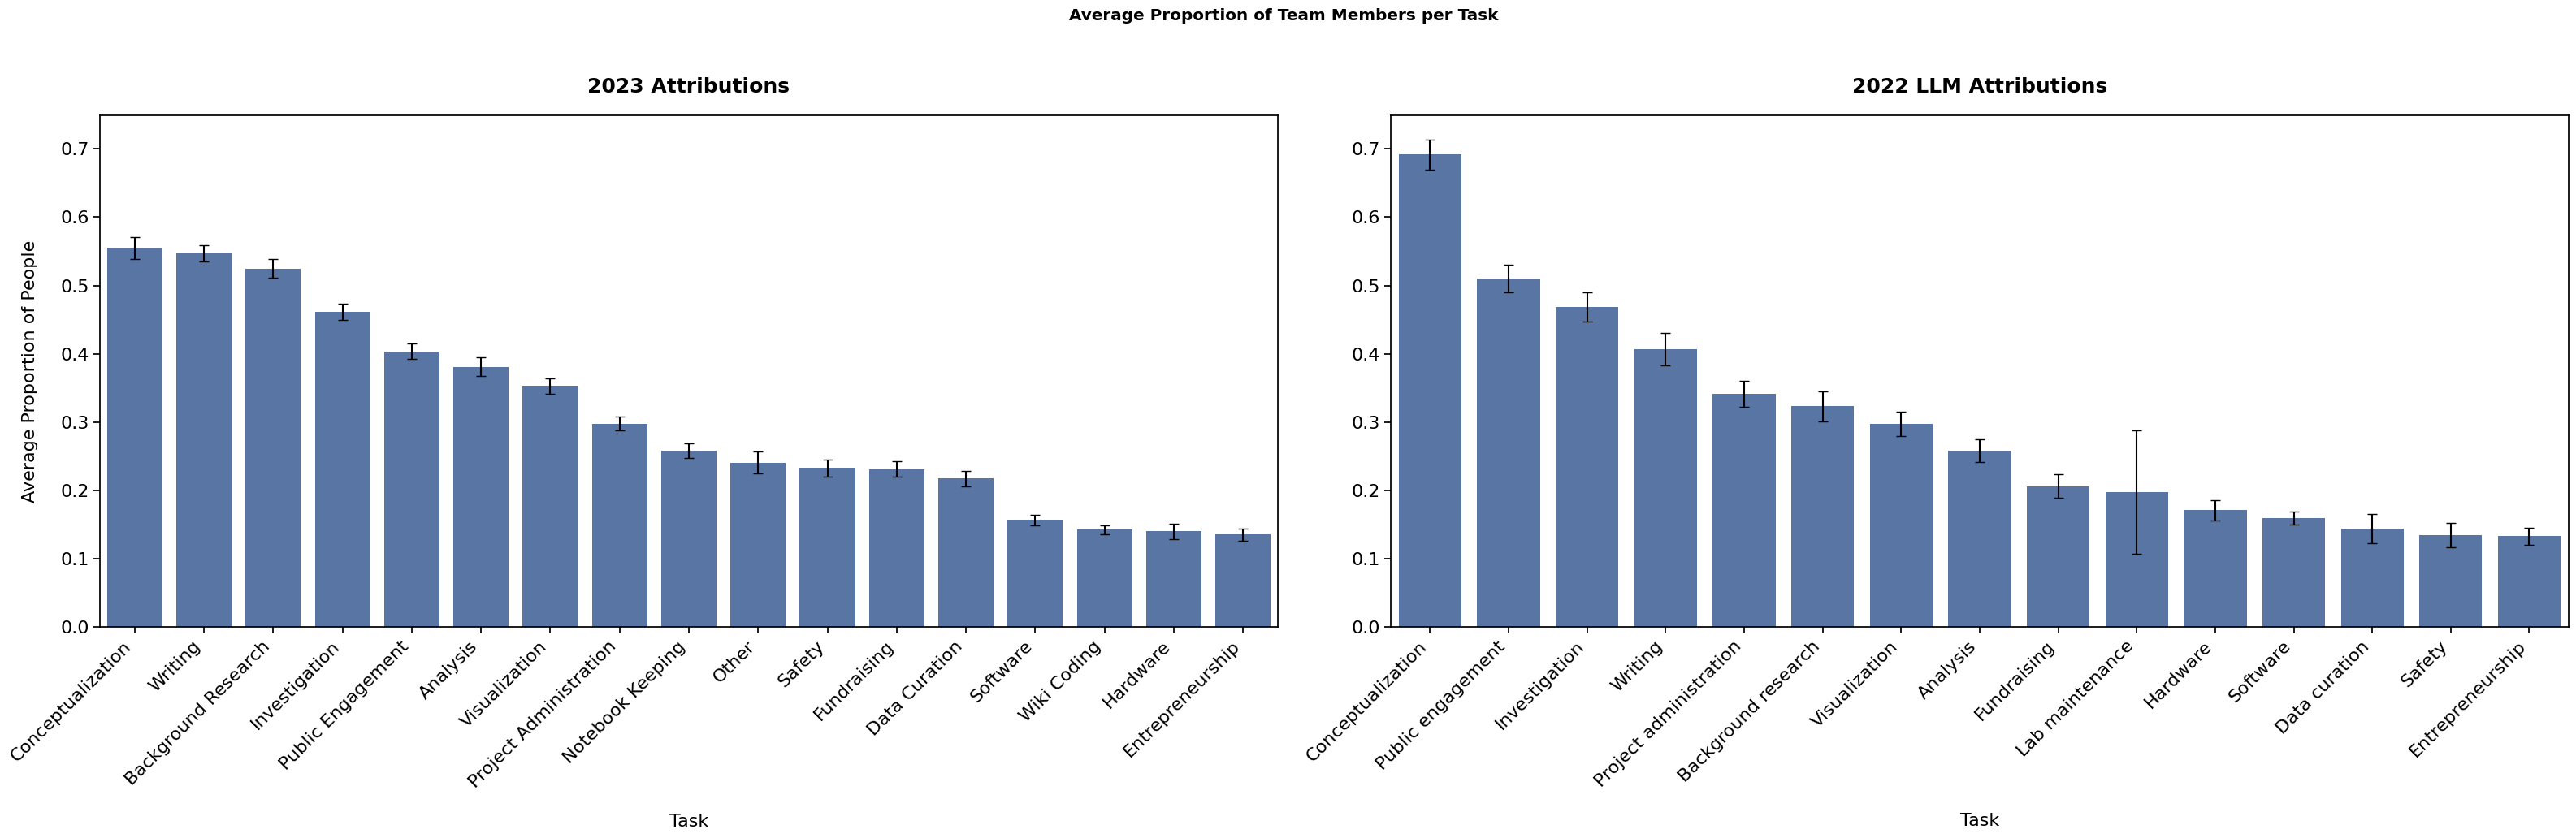

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(32, 10), sharey=True)

for ax, title in zip(axes, DATASET_ORDER):
    agg = (
        team_task_prop_by_dataset[title]
        .groupby("Task")["prop"]
        .agg(['mean', 'std', 'count'])
        .rename(columns={'mean': 'avg_prop', 'std': 'std_prop', 'count': 'n_teams'})
        .sort_values('avg_prop', ascending=False)
    )
    agg['sem_prop'] = agg['std_prop'] / np.sqrt(agg['n_teams'])
    agg = agg.reset_index()

    sns.barplot(data=agg, x="Task", y="avg_prop", errorbar=None, ax=ax)
    ax.errorbar(
        x=range(len(agg)),
        y=agg['avg_prop'],
        yerr=agg['sem_prop'],
        fmt='none',
        c='black',
        capsize=4,
    )
    ax.tick_params(axis='y', labelleft=True)
    ax.yaxis.set_label_position("left")
    ax.set_title(title)
    ax.set_xlabel("Task")
    ax.set_ylabel("Average Proportion of People")
    ax.set_xlim(-0.5, len(agg) - 0.5)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle("Average Proportion of Team Members per Task", y=1.03, weight='bold')
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.show()


**How consistent are those average proportions across all teams?** 

The very small error bars (around +- SEM) show that these percentages don’t vary a lot across teams. When error bars overlap, like for Software and Wiki Coding, that means that the mean percentages for those two tasks are not reliably different at the 95% confidence level (visualization of a t-test). For tasks not overlapping for example Conceptualization and Visualization, we can say that they are performed by different proportions of team members (bigger for Conceptualization). Also, for example, Analysis has a greater SEM than Public Engagement, but they have a similar average percentage of team members performing them. Wiki Coding has the smallest SEM, meaning almost every team assigns this task to a small number of members. Safety and Hardware are on average performed by less than 25% of members, but could be team specific since they have larger SEMs (but still very small like for every team).

## 3. Members Distribution

- is it normal, bounded, with outliers, with power-law? is lin-lin better, or lin-log / log-lin (exponential) or log-log (power-law)?

In [98]:
person_task_by_dataset = {}
people_per_task_instance_by_dataset = {}

for title in DATASET_ORDER:
    person_task = DATASETS[title].drop_duplicates(["TeamID", "Task", "FullName"])
    people_per_task_instance = (
        person_task
        .groupby(["TeamID", "Task"])["FullName"]
        .nunique()
    )
    person_task_by_dataset[title] = person_task
    people_per_task_instance_by_dataset[title] = people_per_task_instance

person_task = person_task_by_dataset["2023 Attributions"]
people_per_task_instance = people_per_task_instance_by_dataset["2023 Attributions"]

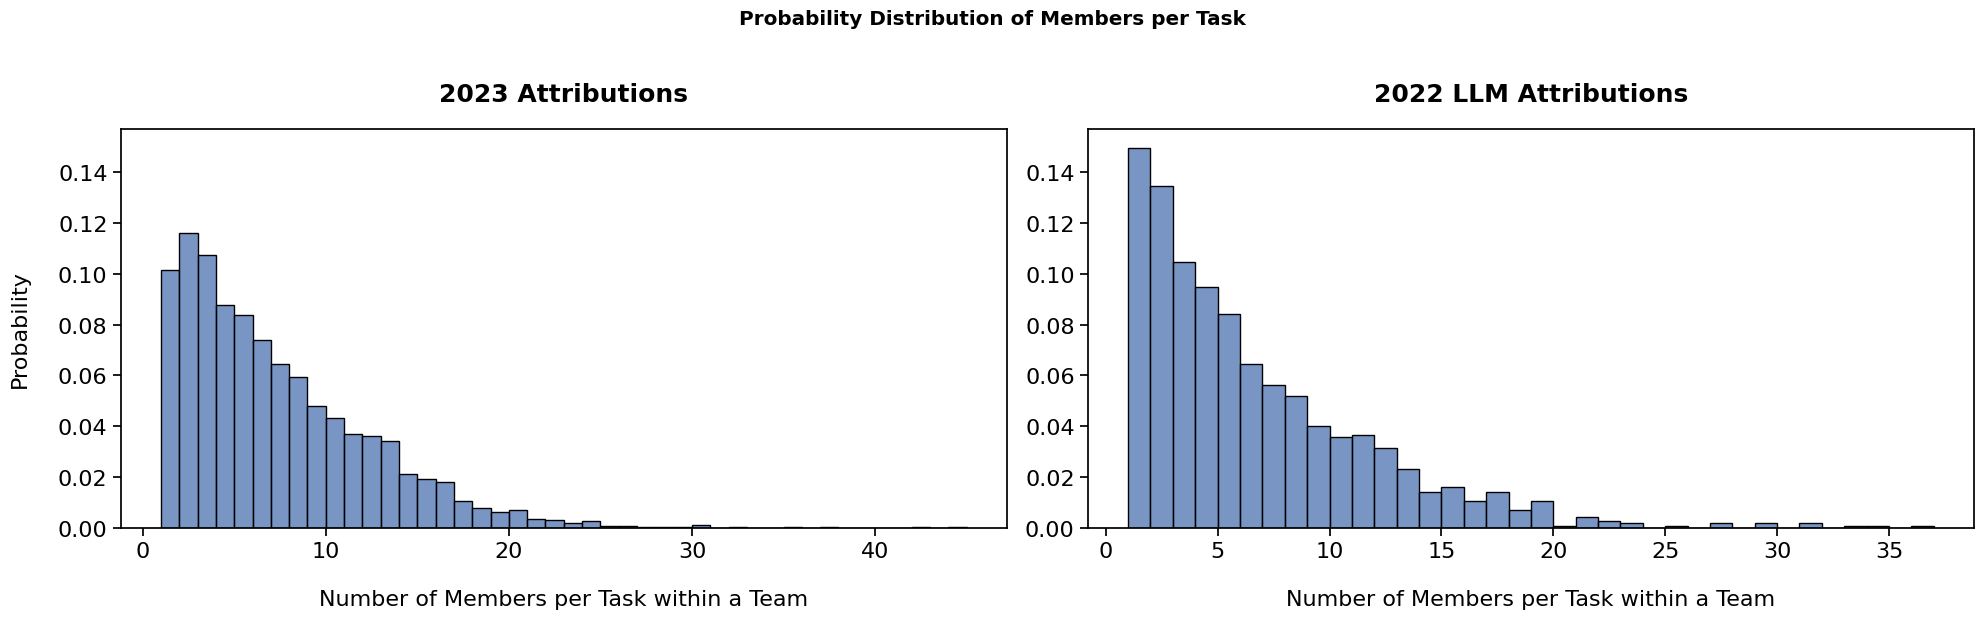

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

for ax, title in zip(axes, DATASET_ORDER):
    s = people_per_task_instance_by_dataset[title]
    sns.histplot(
        s,
        bins=range(1, int(s.max()) + 2),
        stat="probability",
        ax=ax,
    )
    ax.tick_params(axis='y', labelleft=True)
    ax.yaxis.set_label_position("left")
    ax.set_title(title)
    ax.set_xlabel("Number of Members per Task within a Team")
    ax.set_ylabel("Probability")

plt.suptitle("Probability Distribution of Members per Task", y=1.03, weight='bold')
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.show()


- not normal, right-skewed
- long tail with outliers of more than 30 people per task (some bigger teams while the avg num of team members is 23)
- if we plot log-lin or lin-log and the tail appears as a straight line, we have an exponential distribution - few large values, quick fall, bigger groups of people working on the same task are exceptions
- if we plot log-log and the tail appears as a straight line, we have a power-law distribution - heavier tail, large values likely, there is a small number of tasks that require bigger groups of people
- naturally bonded (a person has one task and the num of people per task does not exceed the num of team members)

In [100]:
for title in DATASET_ORDER:
    data = people_per_task_instance_by_dataset[title].values
    fit = powerlaw.Fit(data, discrete=True)
    R, p = fit.distribution_compare('power_law', 'exponential')
    print(f"{title} | Power law alpha: {fit.power_law.alpha}")
    print(f"{title} | Power law xmin: {fit.power_law.xmin}")
    print(f"{title} | Likelihood ratio (R): {R}")
    print(f"{title} | p-value: {p}")

Calculating best minimal value for power law fit
2023 Attributions | Power law alpha: 5.850431204801251
2023 Attributions | Power law xmin: 16.0
2023 Attributions | Likelihood ratio (R): 1.5926769904697293
2023 Attributions | p-value: 0.5945473770382109
Calculating best minimal value for power law fit
2022 LLM Attributions | Power law alpha: 4.117742774732469
2022 LLM Attributions | Power law xmin: 11.0
2022 LLM Attributions | Likelihood ratio (R): -5.107515805810723
2022 LLM Attributions | p-value: 0.07264981425319941


In [101]:
desc_tables = {title: people_per_task_instance_by_dataset[title].describe() for title in DATASET_ORDER}
display(pd.concat(desc_tables, axis=1))

,2023 Attributions,2022 LLM Attributions
count,3821.000000,1117.000000
mean,6.828841,6.205909
std,5.171358,5.221495
min,1.000000,1.000000
25%,3.000000,2.000000
50%,6.000000,5.000000
75%,10.000000,9.000000
max,44.000000,36.000000


Members per task follow a power law distribution better with a positive likelihood ratio R, but this is not statistically significant since p > 0.05. The power-law behavior starts from tasks involving >= 20 members (power law xmin). Alpha tells us about the steepness of the decay, with smaller values representing very heavy tails, slow decays. Here, alpha suggests a more exponential distribution and boundedness.

An exponential distribution would mean:
- the probability of finding a task with a large number of members declines very quickly
- there are very few tasks with many members, and they don’t dominate.
- collaboration sizes are evenly distributed — most tasks have small, bounded groups

Let's see the probability distribution in log-lin, lin-log, and log-log.

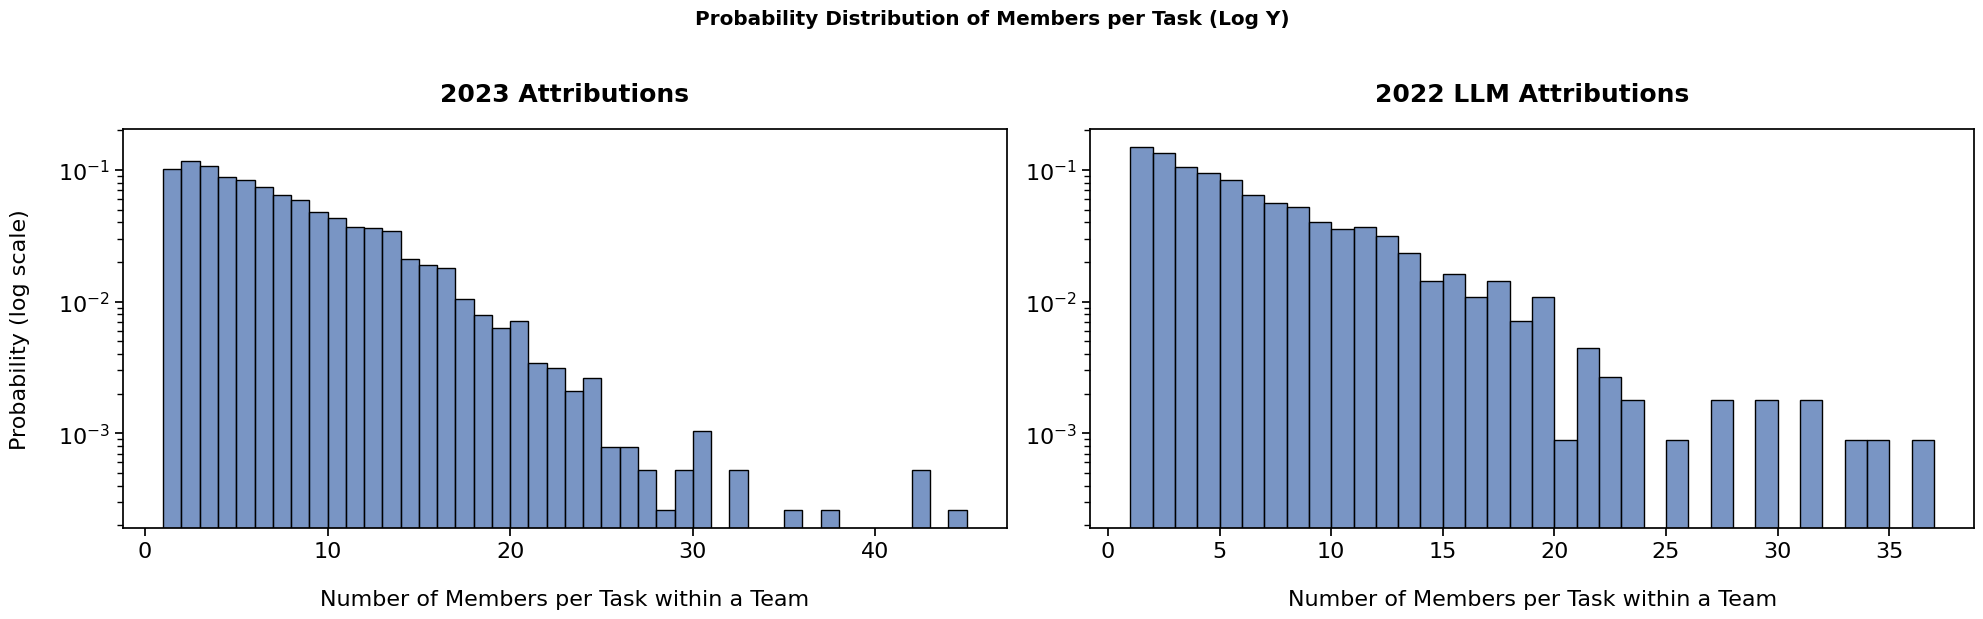

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

for ax, title in zip(axes, DATASET_ORDER):
    s = people_per_task_instance_by_dataset[title]
    sns.histplot(
        s,
        bins=range(1, int(s.max()) + 2),
        stat="probability",
        ax=ax,
    )
    ax.set_yscale("log")
    ax.tick_params(axis='y', labelleft=True)
    ax.yaxis.set_label_position("left")
    ax.set_title(title)
    ax.set_xlabel("Number of Members per Task within a Team")
    ax.set_ylabel("Probability (log scale)")

plt.suptitle("Probability Distribution of Members per Task (Log Y)", y=1.03, weight='bold')
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.show()


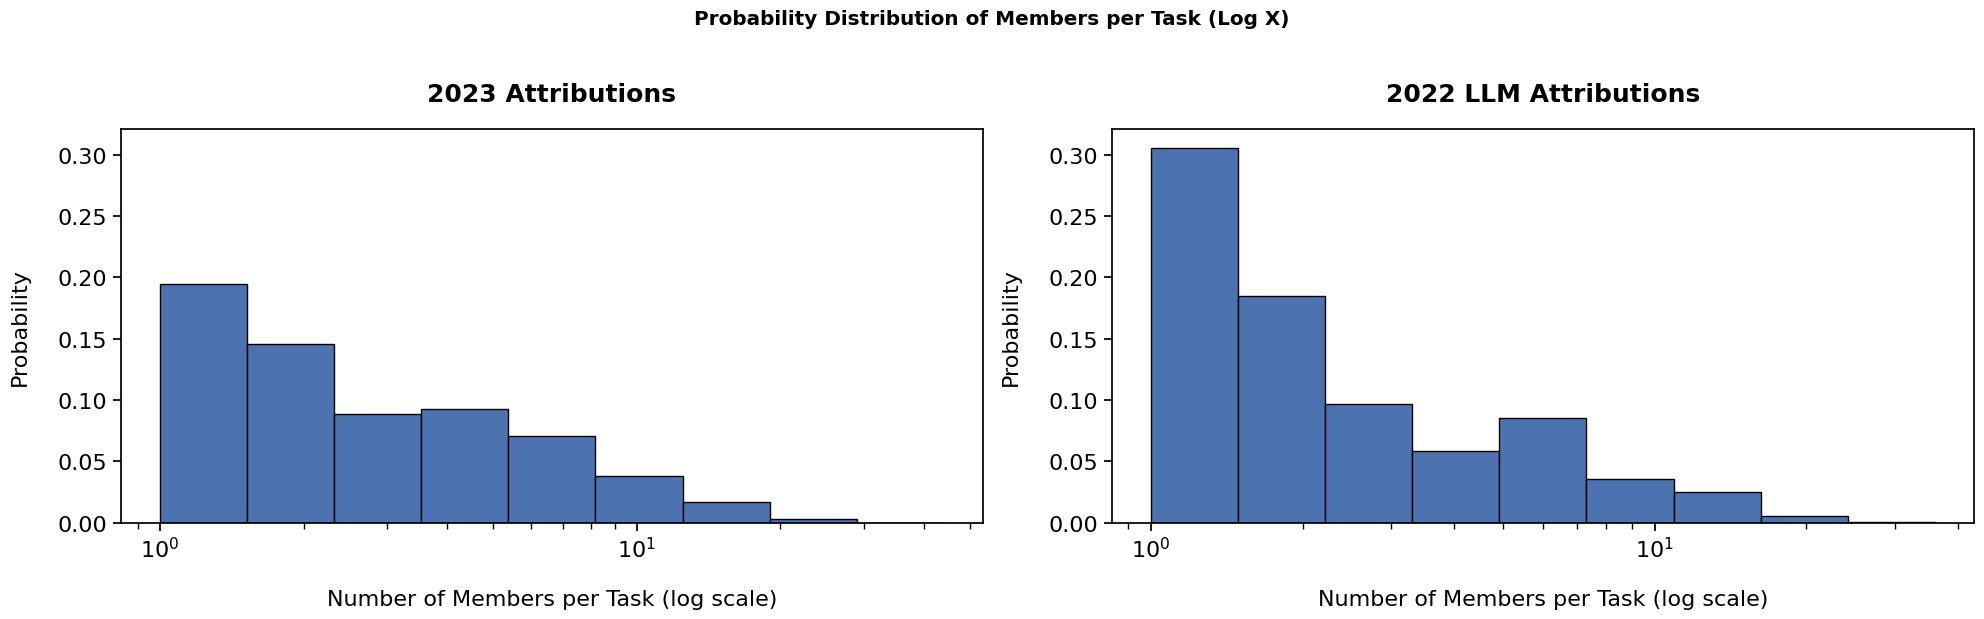

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)
log_bins_by_dataset = {}

for ax, title in zip(axes, DATASET_ORDER):
    s = people_per_task_instance_by_dataset[title]
    min_val = max(1, int(s.min()))
    max_val = int(s.max())
    bins = np.logspace(np.log10(min_val), np.log10(max_val), num=10)
    hist, bin_edges = np.histogram(s, bins=bins)
    dx = np.diff(bin_edges)
    density = hist / (np.sum(hist) * dx)

    log_bins_by_dataset[title] = (bin_edges, dx, density)

    ax.bar(bin_edges[:-1], density, width=dx, align='edge', edgecolor='black')
    ax.set_xscale("log")
    ax.tick_params(axis='y', labelleft=True)
    ax.yaxis.set_label_position("left")
    ax.set_title(title)
    ax.set_xlabel("Number of Members per Task (log scale)")
    ax.set_ylabel("Probability")

plt.suptitle("Probability Distribution of Members per Task (Log X)", y=1.03, weight='bold')
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.show()


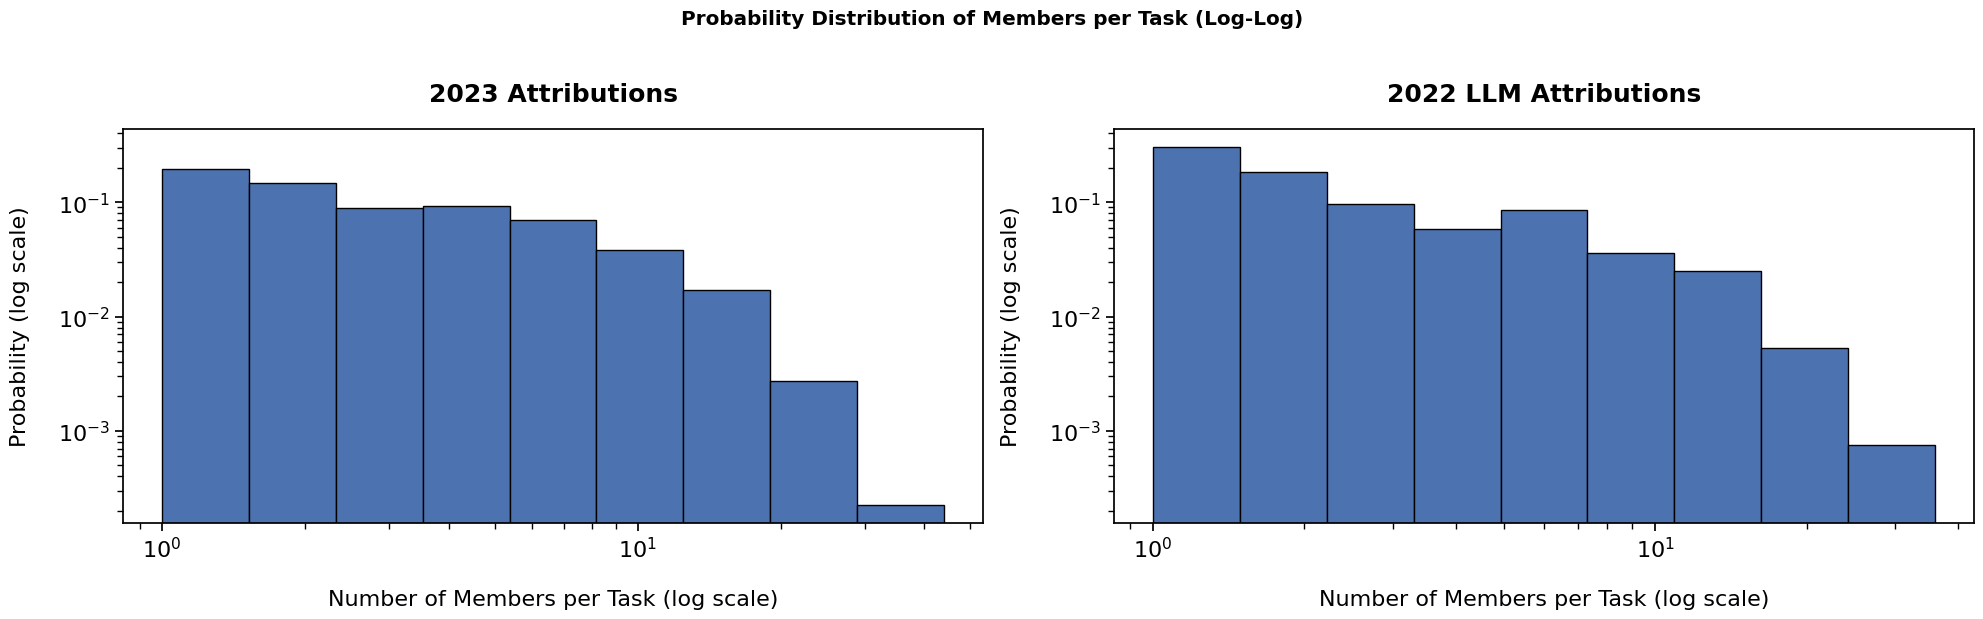

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

for ax, title in zip(axes, DATASET_ORDER):
    bin_edges, dx, density = log_bins_by_dataset[title]
    ax.bar(bin_edges[:-1], density, width=dx, align='edge', edgecolor='black', color=sns.color_palette("deep")[0])
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.tick_params(axis='y', labelleft=True)
    ax.yaxis.set_label_position("left")
    ax.set_title(title)
    ax.set_xlabel("Number of Members per Task (log scale)")
    ax.set_ylabel("Probability (log scale)")

plt.suptitle("Probability Distribution of Members per Task (Log-Log)", y=1.03, weight='bold')
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.show()


## 4. Role-Based Analysis
- proportions of member roles in a typical team
- how does task distribution differ between different roles (students, PIs, advisors, etc.)

In [94]:
role_sizes_by_dataset = {}
for title in DATASET_ORDER:
    role_sizes_by_dataset[title] = (
        DATASETS[title]
        .drop_duplicates(['TeamID', 'Role', 'FullName'])
        .groupby(['TeamID', 'Role'])
        .size()
        .rename('n_role_members')
        .reset_index()
    )

role_sizes = role_sizes_by_dataset["2023 Attributions"]
display(pd.concat(role_sizes_by_dataset, axis=1))

2023 Attributions                                2022 LLM Attributions  \
                TeamID            Role n_role_members                TeamID   
0                 4574         Advisor              2                4118.0   
1                 4574      Instructor              3                4118.0   
2                 4574      Primary PI              1                4118.0   
3                 4574  Student Member             20                4118.0   
4                 4575         Advisor              2                4118.0   
...                ...             ...            ...                   ...   
1209              5019  Student Leader              2                   NaN   
1210              5019  Student Member              9                   NaN   
1211              5027      Primary PI              1                   NaN   
1212              5027  Student Leader              1                   NaN   
1213              5027  Student Member             13                   NaN   

                                     
                Role n_role_members  
0            Advisor            1.0  
1         Instructor            3.0  
2         Primary PI            1.0  
3       Secondary PI            1.0  
4     Student Leader            1.0  
...              ...            ...  
1209             NaN            NaN  
1210             NaN            NaN  
1211             NaN            NaN  
1212             NaN            NaN  
1213             NaN            NaN  

[1214 rows x 6 columns]

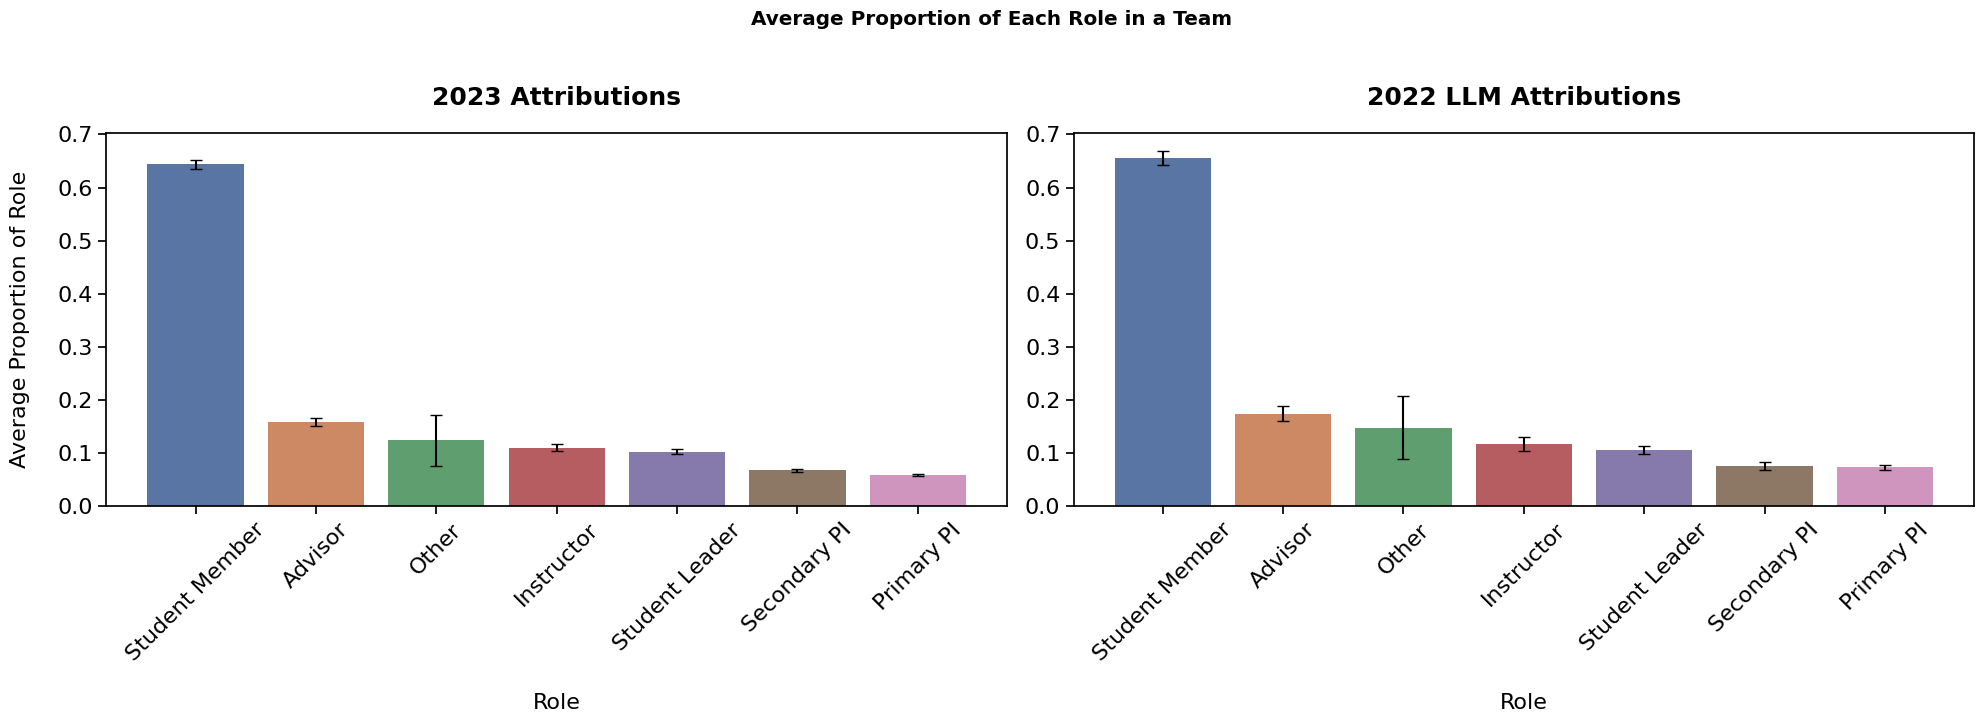

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

for ax, title in zip(axes, DATASET_ORDER):
    role_prop = role_sizes_by_dataset[title].merge(team_sizes_by_dataset[title], on="TeamID")
    role_prop["prop"] = role_prop["n_role_members"] / role_prop["team_size"]

    agg = (
        role_prop
        .groupby("Role")["prop"]
        .agg(['mean', 'std', 'count'])
        .rename(columns={'mean': 'avg_prop', 'std': 'std_prop', 'count': 'n_teams'})
        .sort_values("avg_prop", ascending=False)
    )
    agg['sem_prop'] = agg['std_prop'] / np.sqrt(agg['n_teams'])
    agg = agg.reset_index()

    sns.barplot(
        data=agg,
        x="Role",
        y="avg_prop",
        hue="Role",
        palette="deep",
        dodge=False,
        legend=False,
        errorbar=None,
        ax=ax,
    )

    ax.errorbar(
        x=range(len(agg)),
        y=agg['avg_prop'],
        yerr=agg['sem_prop'],
        fmt='none',
        c='black',
        capsize=4,
    )
    ax.tick_params(axis='y', labelleft=True)
    ax.yaxis.set_label_position("left")
    ax.set_title(title)
    ax.set_xlabel("Role")
    ax.set_ylabel("Average Proportion of Role")
    ax.set_xlim(-0.5, len(agg) - 0.5)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle("Average Proportion of Each Role in a Team", y=1.03, weight='bold')
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.show()


**On average, what proportion of a team is made up by each role, and how consistent is that across teams?**

In a typical team, more than 60% of members are students, while other roles have around 10-15% of members. The error bar is the biggest for the "Other" role, meanimg that the percentage of Other members vary across teams. Error bars for other roles are small, aspecially for PIs, meaning there is less variation across teams for the proportions of those roles.

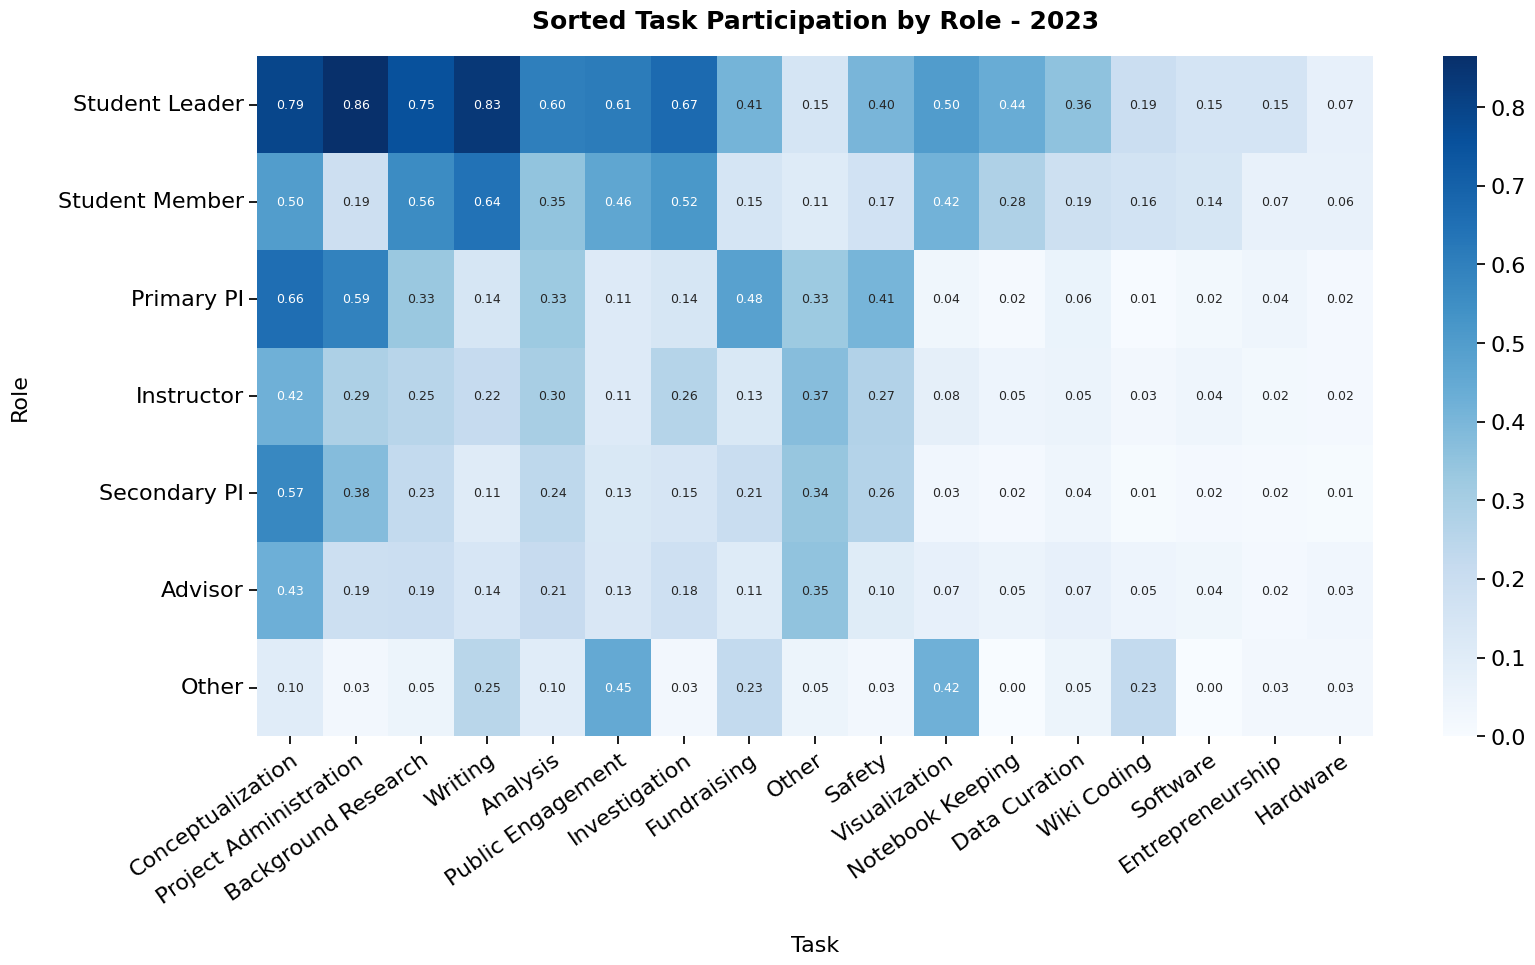

In [130]:
fig, ax = plt.subplots(1, 1, figsize=(18, 8))

dataset_key = "2023 Attributions"
title = "Sorted Task Participation by Role - 2023"

df = DATASETS[dataset_key]
role_task_people = (
    df.groupby(["Role", "Task"])["FullName"]
    .nunique()
    .unstack(fill_value=0)
)

role_totals = (
    df.drop_duplicates(["TeamID", "Role", "FullName"])
    .groupby("Role")["FullName"]
    .nunique()
)

role_task_prop = role_task_people.div(role_totals, axis=0)
sorted_roles = role_task_prop.sum(axis=1).sort_values(ascending=False).index
sorted_tasks = role_task_prop.sum(axis=0).sort_values(ascending=False).index
ordered_matrix = role_task_prop.loc[sorted_roles, sorted_tasks]

sns.heatmap(
    ordered_matrix,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9},
    cbar=True,
    ax=ax,
)
ax.set_title(title)
ax.set_xlabel("Task")
ax.set_ylabel("Role")
ax.set_xlim(0, ordered_matrix.shape[1])
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', rotation_mode='anchor')

plt.subplots_adjust(hspace=0.5, top=0.96)
plt.show()


**What proportion of people within each role performed each task?**

The rows in the previous heatmap are sorted from most generalist (e.g. Student Member) to most specialist (e.g. Other) role. The top-left corner shows generalists doing common tasks in dark blue, while the bottom-right shows specialists doing rare tasks. We can see by these formed triangles that teams divide labor based on the hierarchy of roles. For both student members and leaders roles, the highest number of people participated in Writing, followed by Bacground Research, Investigation and Conceptualization. A big difference between the rolse is found for Project Administration: on average, 20% of student members do that task, while that proportion is 79% amongst student leaders. That percentage is high for the Primary PI role, meaning that student leaders and primary PIs are mostly involved in project administration. 

Tasks like Wiki Coding, Software, Hardware, Entrepreneurship have low participation within each role, as seen before. Conceptualization is popular within every role except Other. The role Others mostly helps with Visualization, though we saw that this role varies across teams. Most of Instructors and Advisors focus on Conceptualization. Student members are not that involved in Fundraising, and that task is mostly popular within the Primary PI role. 

This heatmap shows that technical and documentation tasks are primarily performed by students, while administrative, strategic, and outreach-related tasks are more commonly performed by PIs, instructors, and advisors.

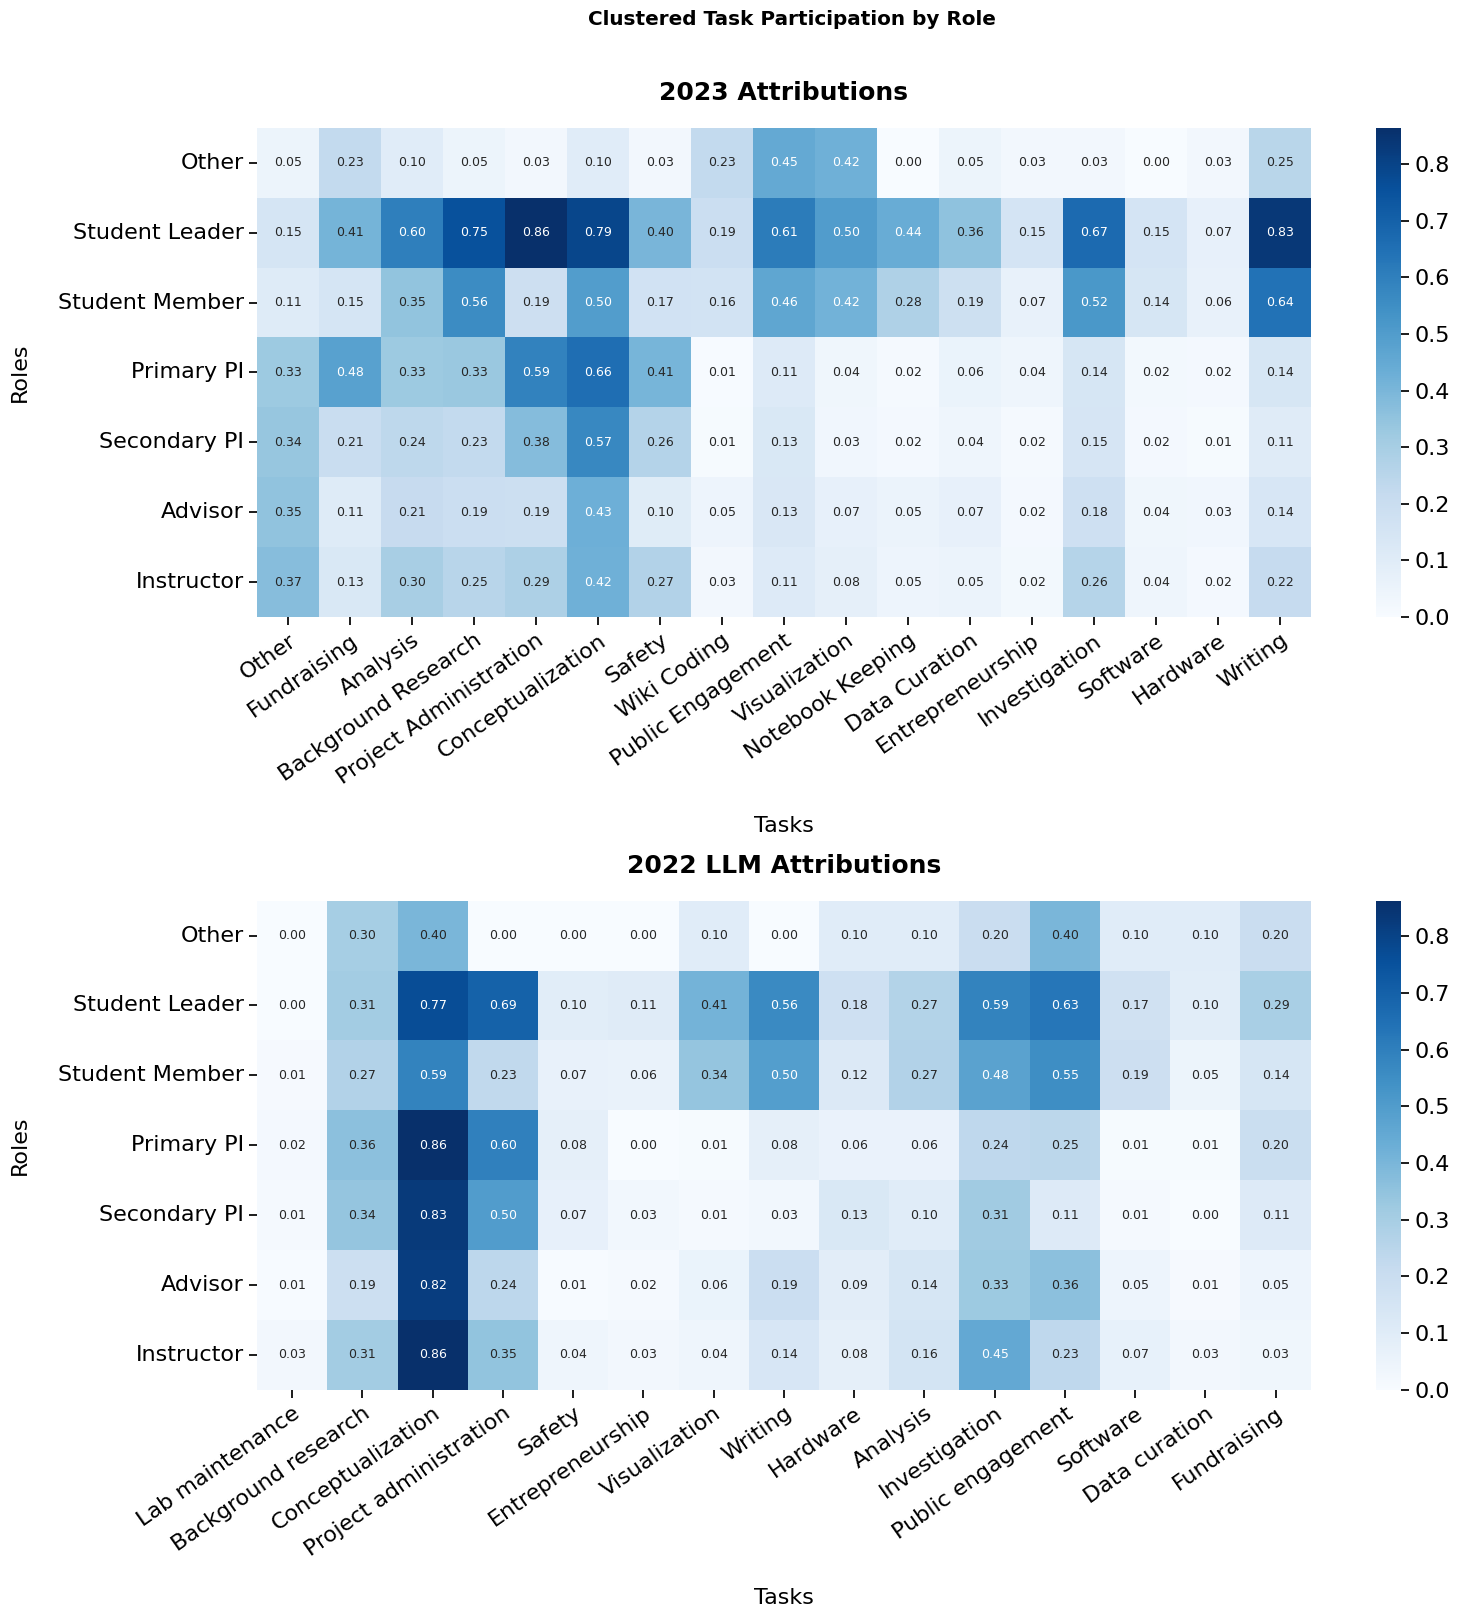

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 16))

for ax, title in zip(axes, DATASET_ORDER):
    df = DATASETS[title]
    role_task_people = (
        df.groupby(["Role", "Task"])["FullName"]
        .nunique()
        .unstack(fill_value=0)
    )
    role_totals = (
        df.drop_duplicates(["TeamID", "Role", "FullName"])
        .groupby("Role")["FullName"]
        .nunique()
    )
    role_task_prop = role_task_people.div(role_totals, axis=0).fillna(0)

    row_order = leaves_list(linkage(pdist(role_task_prop.values, metric="cosine"), method="average"))
    col_order = leaves_list(linkage(pdist(role_task_prop.T.values, metric="cosine"), method="average"))
    ordered = role_task_prop.iloc[row_order, col_order]

    sns.heatmap(
        ordered,
        cmap="Blues",
        annot=True,
        fmt=".2f",
        annot_kws={"size": 9},
        cbar=True,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Tasks")
    ax.set_ylabel("Roles")
    ax.set_xlim(0, ordered.shape[1])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', rotation_mode='anchor')

plt.suptitle("Clustered Task Participation by Role", y=0.995, weight='bold')
plt.subplots_adjust(hspace=0.5, top=0.96)
plt.show()


Similarly as before, the dendograms show a clear separation between generalist and specialization tasks and roles. Student roles cluster together and show high involvement across many hands-on tasks. Instructors, Advisors, and PIs form a separate cluster with more strategic or supervisory tasks

Tasks like Notebook Keeping and Wiki Coding cluster together as documentation tasks mainly handled by students. Supervision-oriented tasks like Project Administration and Safety are more related to higher team member roles.

## 5. Tasks per Role

- visualizations of the average number of tasks per role

/var/folders/25/xdw_br_122j5ypnmb925dfjw0000gn/T/ipykernel_58345/3285658017.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/25/xdw_br_122j5ypnmb925dfjw0000gn/T/ipykernel_58345/3285658017.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


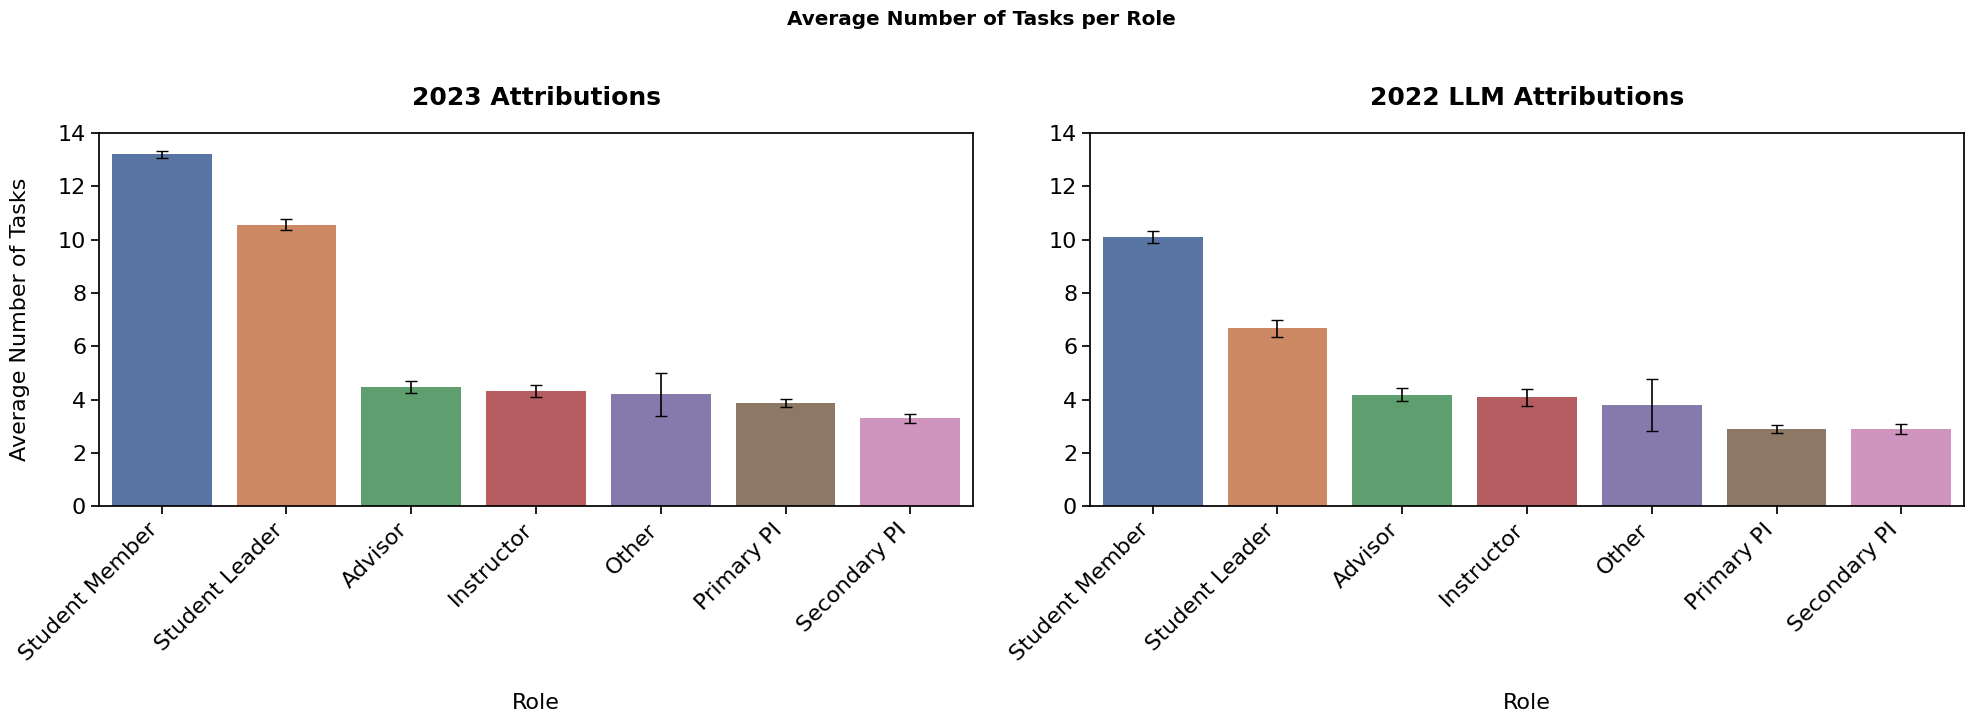

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

for ax, title in zip(axes, DATASET_ORDER):
    tasks_per_team_role = (
        DATASETS[title]
        .groupby(["TeamID", "Role"])["Task"]
        .nunique()
        .reset_index(name="n_unique_tasks")
    )

    agg = (
        tasks_per_team_role
        .groupby("Role")["n_unique_tasks"]
        .agg(["mean", "std", "count"])
        .rename(columns={"mean": "avg", "std": "std", "count": "n"})
        .sort_values("avg", ascending=False)
    )
    agg["sem"] = agg["std"] / np.sqrt(agg["n"])

    sns.barplot(
        data=agg.reset_index(),
        x="Role",
        y="avg",
        hue="Role",
        palette="deep",
        dodge=False,
        legend=False,
        errorbar=None,
        ax=ax,
    )
    ax.errorbar(
        x=np.arange(len(agg)),
        y=agg["avg"],
        yerr=agg["sem"],
        fmt="none",
        capsize=4,
        color="black",
        linewidth=1.2,
    )
    ax.tick_params(axis='y', labelleft=True)
    ax.yaxis.set_label_position("left")
    ax.set_title(title)
    ax.set_xlabel("Role")
    ax.set_ylabel("Average Number of Tasks")
    ax.set_xlim(-0.5, len(agg) - 0.5)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle("Average Number of Tasks per Role", y=1.03, weight='bold')
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.show()


**On average, how many different tasks does each team role handle within a team, and how consistent is that number across all teams?** 

Students tend to have the most number of tasks within a team (~13), while student leaders tend to have a bit less (~11). The variances between teams are not big except for the Other role again.

## 6. Tasks Distribution

- is it normal, bounded, with outliers, with power-law? is lin-lin better, or lin-log / log-lin (exponential) or log-log (power-law)?

In [106]:
tasks_per_person_by_dataset = {}
for title in DATASET_ORDER:
    person_task = DATASETS[title].drop_duplicates(["TeamID", "FullName", "Task"])
    tasks_per_person_by_dataset[title] = (
        person_task
        .groupby(["TeamID", "FullName"])["Task"]
        .nunique()
    )

tasks_per_person = tasks_per_person_by_dataset["2023 Attributions"]

In [107]:
desc_tasks_per_person = {title: s.describe() for title, s in tasks_per_person_by_dataset.items()}
display(pd.concat(desc_tasks_per_person, axis=1))

,2023 Attributions,2022 LLM Attributions
count,5647.000000,1890.000000
mean,4.620684,3.667725
std,3.029946,1.931233
min,1.000000,1.000000
25%,2.000000,2.000000
50%,4.000000,3.000000
75%,7.000000,5.000000
max,16.000000,14.000000


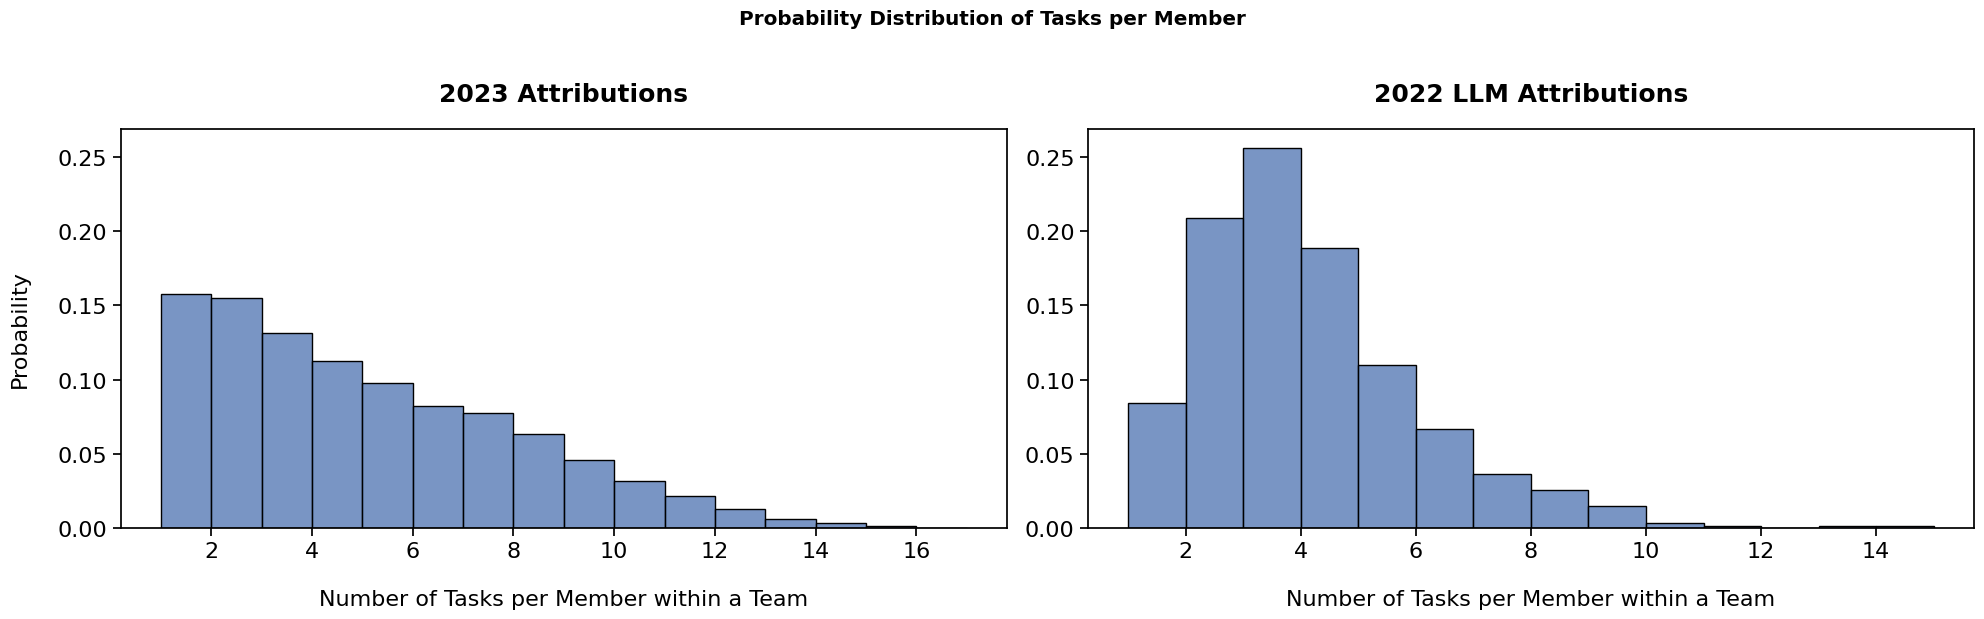

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

for ax, title in zip(axes, DATASET_ORDER):
    s = tasks_per_person_by_dataset[title]
    sns.histplot(
        s,
        bins=range(1, int(s.max()) + 2),
        stat="probability",
        ax=ax,
    )
    ax.tick_params(axis='y', labelleft=True)
    ax.yaxis.set_label_position("left")
    ax.set_title(title)
    ax.set_xlabel("Number of Tasks per Member within a Team")
    ax.set_ylabel("Probability")

plt.suptitle("Probability Distribution of Tasks per Member", y=1.03, weight='bold')
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.show()


In [109]:
for title in DATASET_ORDER:
    data = tasks_per_person_by_dataset[title].values
    fit = powerlaw.Fit(data, discrete=True)
    R, p = fit.distribution_compare('power_law', 'exponential')
    print(f"{title} | Power law alpha: {fit.power_law.alpha}")
    print(f"{title} | Power law xmin: {fit.power_law.xmin}")
    print(f"{title} | Likelihood ratio (R): {R}")
    print(f"{title} | p-value: {p}")

Calculating best minimal value for power law fit
2023 Attributions | Power law alpha: 10.867464089406651
2023 Attributions | Power law xmin: 12.0
2023 Attributions | Likelihood ratio (R): -2.1547270513026873
2023 Attributions | p-value: 1.5219719952624739e-06
Calculating best minimal value for power law fit
2022 LLM Attributions | Power law alpha: 5.0335700544914905
2022 LLM Attributions | Power law xmin: 6.0
2022 LLM Attributions | Likelihood ratio (R): -8.331912929314258
2022 LLM Attributions | p-value: 0.0001798575067172861


Most people only do a few tasks since the distribution is likely the exponential one and not a power law, with R < 0 and p < 0.05. That means there are no super-contributors dominating the task distribution.
On the other side, a power-law distribution would suggest that there are do-it-all people whom other members would ask for help because they already perform a lot of tasks. We can visualize the exponential distribution by loging the x and y axis.

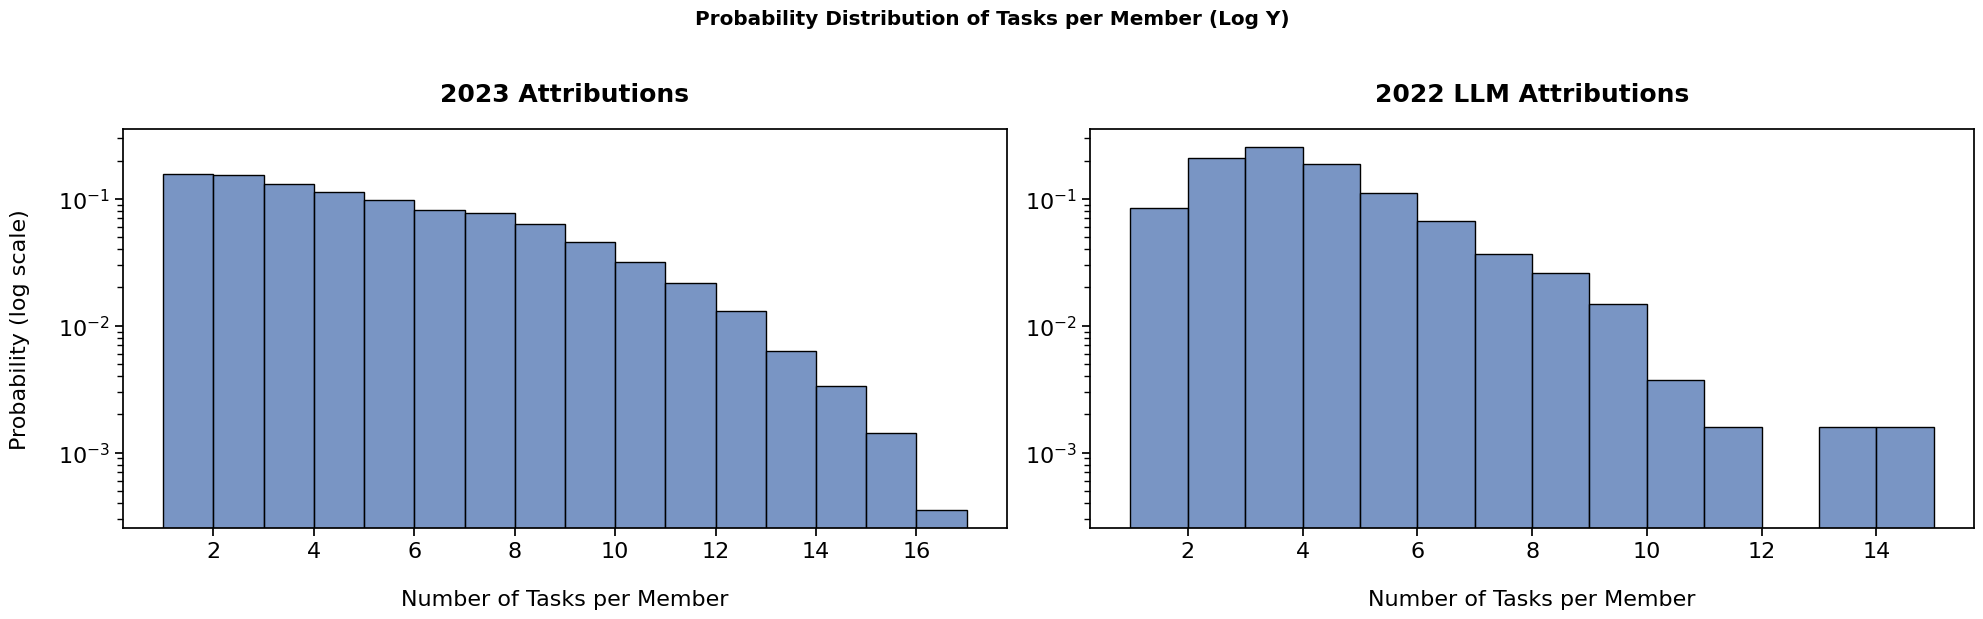

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

for ax, title in zip(axes, DATASET_ORDER):
    s = tasks_per_person_by_dataset[title]
    sns.histplot(
        s,
        bins=range(1, int(s.max()) + 2),
        edgecolor="black",
        stat="probability",
        ax=ax,
    )
    ax.set_yscale("log")
    ax.tick_params(axis='y', labelleft=True)
    ax.yaxis.set_label_position("left")
    ax.set_title(title)
    ax.set_xlabel("Number of Tasks per Member")
    ax.set_ylabel("Probability (log scale)")

plt.suptitle("Probability Distribution of Tasks per Member (Log Y)", y=1.03, weight='bold')
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.show()


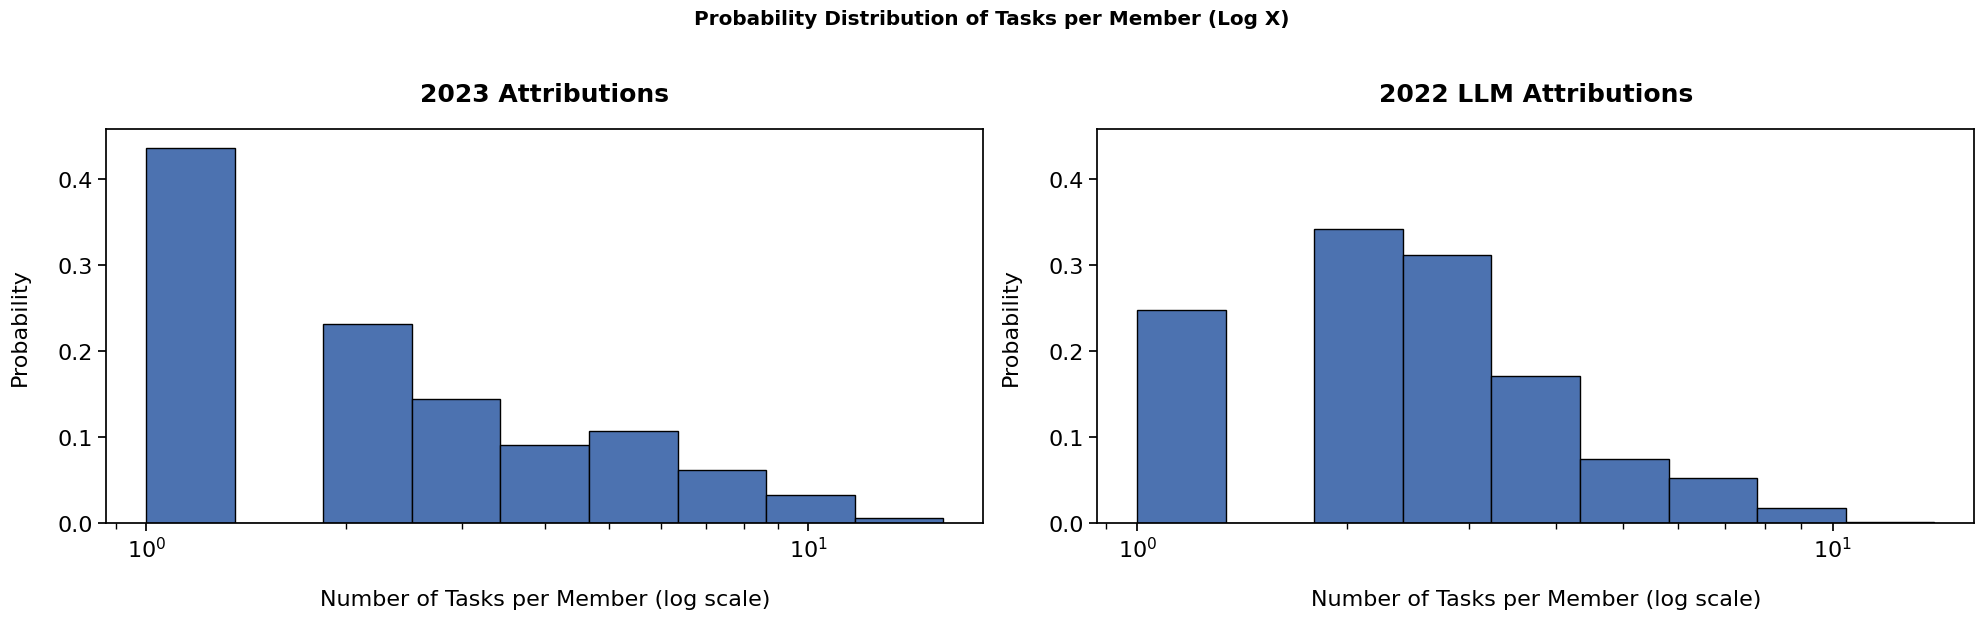

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)
task_log_bins_by_dataset = {}

for ax, title in zip(axes, DATASET_ORDER):
    s = tasks_per_person_by_dataset[title]
    min_val = max(1, int(s.min()))
    max_val = int(s.max())
    bins = np.logspace(np.log10(min_val), np.log10(max_val), num=10)

    hist, bin_edges = np.histogram(s.values, bins=bins, density=False)
    dx = np.diff(bin_edges)
    prob_density = hist / (np.sum(hist) * dx)
    task_log_bins_by_dataset[title] = (bin_edges, dx, prob_density)

    ax.bar(bin_edges[:-1], prob_density, width=dx, align='edge', edgecolor='black')
    ax.set_xscale('log')
    ax.tick_params(axis='y', labelleft=True)
    ax.yaxis.set_label_position("left")
    ax.set_title(title)
    ax.set_xlabel("Number of Tasks per Member (log scale)")
    ax.set_ylabel("Probability")

plt.suptitle("Probability Distribution of Tasks per Member (Log X)", y=1.03, weight='bold')
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.show()


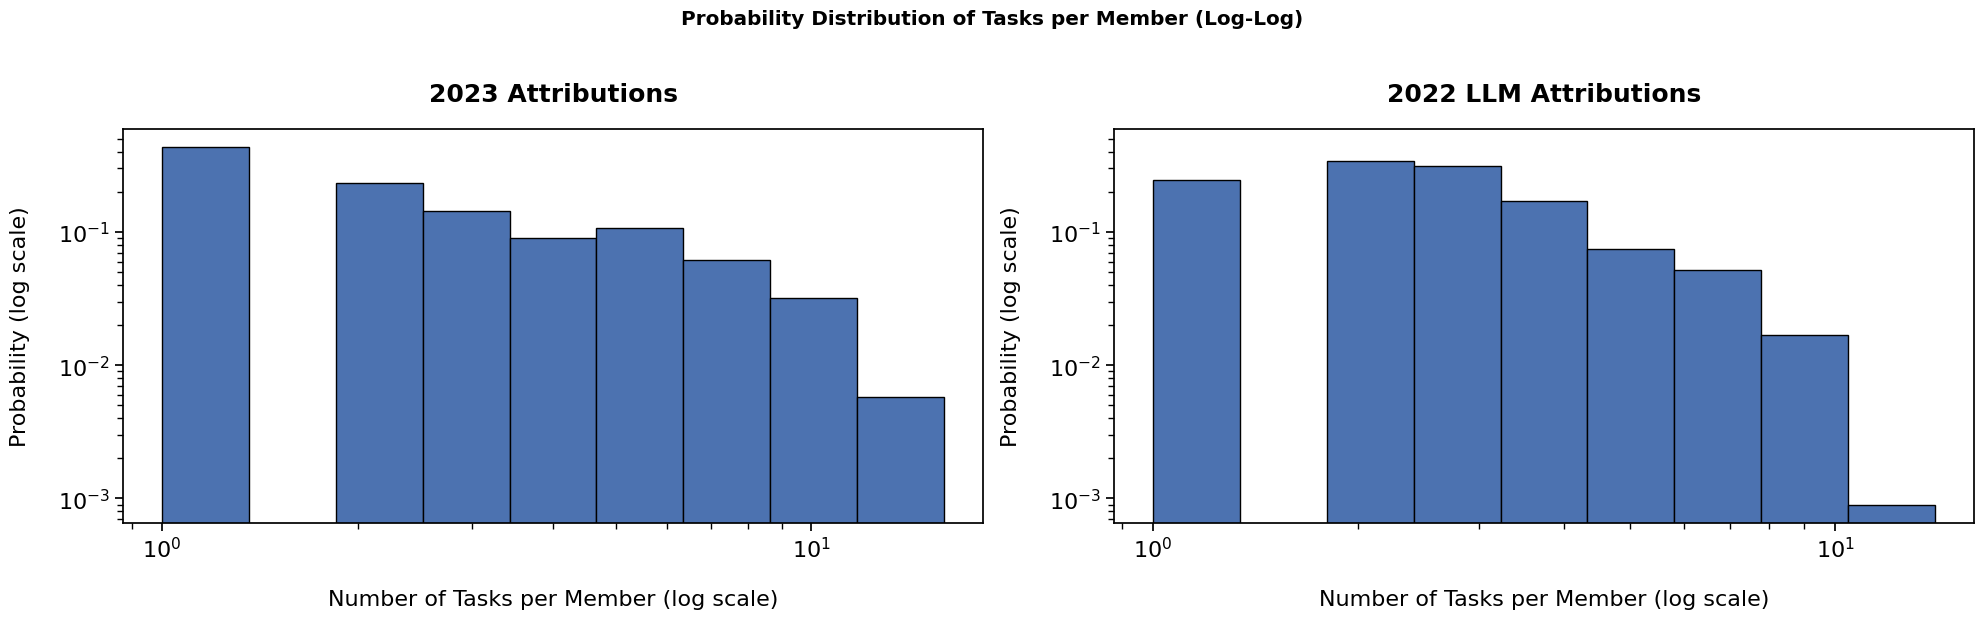

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

for ax, title in zip(axes, DATASET_ORDER):
    bin_edges, dx, prob_density = task_log_bins_by_dataset[title]
    ax.bar(bin_edges[:-1], prob_density, width=dx, align='edge', edgecolor='black')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(axis='y', labelleft=True)
    ax.yaxis.set_label_position("left")
    ax.set_title(title)
    ax.set_xlabel("Number of Tasks per Member (log scale)")
    ax.set_ylabel("Probability (log scale)")

plt.suptitle("Probability Distribution of Tasks per Member (Log-Log)", y=1.03, weight='bold')
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.show()


Both the members per task and tasks per member distributions are bounded and light-tailed (especially tasks per member). Collaboration in the teams is decentralized and balanced and not driven by a few very big tasks or individuals performing a lot of tasks. Together, these distributions tell us that teams form small groups that handle specific tasks without intertwining a lot with other groups (but this modularity can be better seen on a network graph of tasks and members). Here we only looked at grad teams, and not the high school ones. 